# Generational Voices in Fashion
## An NLP Analysis of Gen Z vs. Older Consumer Reviews

**Module:** MSIN0221 — Natural Language Processing  
**Dataset:** Women's E-Commerce Clothing Reviews (~23,000 reviews)  
**Research Question:** Do Generation Z consumers (18–26) use systematically different language, sentiment, and vocabulary than older consumers (27+) when reviewing clothing online?

---

This notebook presents a complete five-phase NLP pipeline:

| Phase | Focus | Method |
|---|---|---|
| 1 | Data Preparation & EDA | Cleaning, segmentation, visualisation |
| 2 | Sentiment Analysis | VADER (lexicon) + DistilBERT (transformer) |
| 3 | Topic Modelling | Latent Dirichlet Allocation, aspect-level sentiment |
| 4 | Linguistic Analysis | Feature extraction, TF-IDF, LR + RF classification |
| 5 | Evaluation & Synthesis | Error analysis, cross-phase findings |

**Run cells in order.** Phases 1 and 2 load from pre-computed outputs. Phase 3 (LDA) is the only computationally intensive step — see `FAST_MODE` below.

---
## Section 0 — Setup & Configuration

All runtime flags, path constants, colour palettes, and helper functions are defined here. **Run this section first before any other section.** Key flags to know:

| Flag | Default | Effect |
|---|---|---|
| `FAST_MODE` | `False` | `True` reduces LDA passes/k-values and RF trees for faster iteration |
| `FORCE_RECOMPUTE` | `False` | `True` re-runs VADER and DistilBERT inference even if the CSV already exists |

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# EXECUTION FLAGS
# Adjust these before running the full notebook.
# ─────────────────────────────────────────────────────────────────────────────

# FAST_MODE: reduces the LDA coherence sweep to k ∈ {8, 10} with 5 passes each.
# Full sweep (k ∈ {6,8,10,12,15}, 10 passes) takes ~15–20 min on CPU.
# Fast sweep takes ~4 min. Results are slightly less thorough but adequate.
FAST_MODE = False

# FORCE_RECOMPUTE: when True, ignores any pre-saved CSVs and reruns all
# computations from scratch. Useful for reproducibility audits.
# When False (default), Phases 1 and 2 load from saved outputs.
FORCE_RECOMPUTE = False

print(f"FAST_MODE       = {FAST_MODE}")
print(f"FORCE_RECOMPUTE = {FORCE_RECOMPUTE}")

FAST_MODE       = False
FORCE_RECOMPUTE = False


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import ast
import re
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import Image, display, Markdown
from tqdm.notebook import tqdm

# ── scipy / sklearn ───────────────────────────────────────────────────────────
from scipy.stats import ttest_ind
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc
)

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize

# ── Gensim (LDA) ──────────────────────────────────────────────────────────────
try:
    from gensim import corpora
    from gensim.models import LdaModel
    from gensim.models.coherencemodel import CoherenceModel
    _GENSIM_OK = True
except ImportError:
    _GENSIM_OK = False
    print("[WARNING] gensim not found — Section 3 (Topic Modelling) will not run.")
    print("          Install with: pip install gensim")

# ── VADER ─────────────────────────────────────────────────────────────────────
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    _VADER_OK = True
except ImportError:
    _VADER_OK = False
    print("[WARNING] vaderSentiment not found — VADER recompute unavailable.")
    print("          Install with: pip install vaderSentiment")

# ── WordCloud (EDA word clouds) ────────────────────────────────────────────────
try:
    from wordcloud import WordCloud
    _WORDCLOUD_OK = True
except ImportError:
    _WORDCLOUD_OK = False
    print("[WARNING] wordcloud not found — word cloud cells will be skipped.")
    print("          Install with: pip install wordcloud")

# ── pyLDAvis (optional interactive topic viewer) ──────────────────────────────
try:
    import pyLDAvis
    import pyLDAvis.gensim_models as gensimvis
    pyLDAvis.enable_notebook()
    _PYLDAVIS_OK = True
except ImportError:
    _PYLDAVIS_OK = False
    # Non-critical — only affects the interactive LDA visualisation cell

warnings.filterwarnings("ignore")

print("Core imports OK.")
print(f"  gensim     : {'✓' if _GENSIM_OK     else '✗  — pip install gensim'}")
print(f"  vaderSent  : {'✓' if _VADER_OK      else '✗  — pip install vaderSentiment'}")
print(f"  wordcloud  : {'✓' if _WORDCLOUD_OK  else '✗  — pip install wordcloud'}")
print(f"  pyLDAvis   : {'✓' if _PYLDAVIS_OK   else '✗  (optional — interactive topic viewer only)'}")

[WARNING] wordcloud not found — word cloud cells will be skipped.
          Install with: pip install wordcloud
Core imports OK.
  gensim     : ✓
  vaderSent  : ✓
  wordcloud  : ✗  — pip install wordcloud
  pyLDAvis   : ✓


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# NLTK RESOURCE DOWNLOADS
# Downloads are skipped silently if the resource is already cached.
# ─────────────────────────────────────────────────────────────────────────────
_NLTK_RESOURCES = [
    "punkt",          # sentence tokeniser
    "punkt_tab",      # newer punkt tables (NLTK ≥ 3.8)
    "stopwords",      # English stopword list
    "wordnet",        # WordNet lemmatiser (used in LDA tokenisation)
    "omw-1.4",        # Open Multilingual WordNet (WordNet dependency)
    "averaged_perceptron_tagger",  # POS tagger (used by WordNet lemmatiser)
]

for _res in _NLTK_RESOURCES:
    nltk.download(_res, quiet=True)

# Instantiate stopwords and lemmatiser once — reused across Sections 3 and 4
STOP_WORDS = set(stopwords.words("english"))
lemmatiser = WordNetLemmatizer()

print("NLTK resources ready.")

NLTK resources ready.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# PATH SETUP
# All paths are resolved relative to the repository root so the notebook works
# regardless of which working directory Jupyter was launched from, as long as
# it is launched from within the repo.
# ─────────────────────────────────────────────────────────────────────────────

# Notebooks don't have __file__, so we use cwd and walk up until we find
# the repo root (identified by the presence of data/raw/).
def _find_repo_root(start: Path, marker: str = "data/raw") -> Path:
    """Walk up from `start` until a directory containing `marker` is found."""
    candidate = start.resolve()
    for _ in range(6):  # search up to 6 levels — avoids infinite loops
        if (candidate / marker).exists():
            return candidate
        candidate = candidate.parent
    raise FileNotFoundError(
        f"Could not locate repository root (looked for '{marker}' starting from {start}).\n"
        "Launch Jupyter from inside the cloned repository."
    )

ROOT     = _find_repo_root(Path.cwd())
DATA_RAW = ROOT / "data" / "raw"
DATA_PROC = ROOT / "data" / "processed"
OUTPUTS  = ROOT / "outputs"

# Ensure output directories exist (they should already, but safe to guarantee)
DATA_PROC.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

# ── Named paths for every file this notebook reads or writes ─────────────────
# Inputs
RAW_CSV       = DATA_RAW  / "Womens Clothing E-Commerce Reviews.csv"
CLEAN_CSV     = DATA_PROC / "reviews_clean.csv"
SENTIMENT_CSV = DATA_PROC / "reviews_sentiment.csv"
TOPICS_CSV    = DATA_PROC / "reviews_topics.csv"

# Outputs — sentiment (pre-computed)
OUT_SENT_TTEST   = OUTPUTS / "sentiment_ttest_results.csv"
OUT_SENT_AGREE   = OUTPUTS / "sentiment_model_agreement.csv"
OUT_SENT_DEPT    = OUTPUTS / "sentiment_by_department.csv"

# Outputs — topic modelling
OUT_COHERENCE    = OUTPUTS / "lda_coherence_scores.csv"
OUT_ASPECT_SENT  = OUTPUTS / "aspect_sentiment_by_group.csv"
OUT_ASPECT_TTEST = OUTPUTS / "aspect_ttest_results.csv"
OUT_TFIDF_TERMS  = OUTPUTS / "tfidf_top_terms.csv"

# Outputs — linguistic
OUT_LING_SUMMARY = OUTPUTS / "linguistic_features_summary.csv"
OUT_LING_TTEST   = OUTPUTS / "linguistic_ttest_results.csv"
OUT_CLF_LR       = OUTPUTS / "clf_logistic_report.csv"
OUT_CLF_RF       = OUTPUTS / "clf_rf_report.csv"
OUT_CLF_COMPARE  = OUTPUTS / "clf_comparison.csv"

# Outputs — evaluation
OUT_ERROR        = OUTPUTS / "error_analysis.csv"
OUT_SUMMARY_MD   = OUTPUTS / "results_summary.md"

print(f"Repository root : {ROOT}")
print(f"Data (raw)      : {DATA_RAW}")
print(f"Data (processed): {DATA_PROC}")
print(f"Outputs         : {OUTPUTS}")

Repository root : /Users/prishitanahata/Documents/Nlp Group
Data (raw)      : /Users/prishitanahata/Documents/Nlp Group/data/raw
Data (processed): /Users/prishitanahata/Documents/Nlp Group/data/processed
Outputs         : /Users/prishitanahata/Documents/Nlp Group/outputs


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONSTANTS
# Single source of truth for visual style, seeds, and LDA parameters.
# ─────────────────────────────────────────────────────────────────────────────

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Visual identity ────────────────────────────────────────────────────────────
# Consistent palette used in every figure: purple for Gen Z, coral-pink for Older.
PALETTE   = {"gen_z": "#6C63FF", "older": "#FF6584"}
GROUP_ORDER = ["gen_z", "older"]          # canonical display order
GROUP_COL   = "age_group"                    # column name for age group
TEXT_COL    = "review_text"                   # column name for review text
LABELS    = {"gen_z": "Gen Z (18–26)", "older": "Older (27+)"}  # legend labels

FIGSIZE   = (10, 6)    # default figure dimensions (inches)
DPI       = 150        # resolution for saved figures
FIG_KW    = dict(figsize=FIGSIZE, dpi=DPI)  # unpack into plt.subplots(**FIG_KW)

# ── Seaborn / matplotlib global style ─────────────────────────────────────────
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi"       : DPI,
    "savefig.dpi"      : DPI,
    "savefig.bbox"     : "tight",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "sans-serif",
})

# ── LDA sweep parameters (modified by FAST_MODE) ──────────────────────────────
if FAST_MODE:
    LDA_K_VALUES = [8, 10]          # reduced k range
    LDA_PASSES   = 5                # reduced passes per model
    print("[FAST_MODE] LDA sweep: k ∈ {8, 10}, 5 passes each (~4 min)")
else:
    LDA_K_VALUES = [6, 8, 10, 12, 15]   # full sweep from nlp_3_topic_modelling.py
    LDA_PASSES   = 10
    print("[FULL MODE] LDA sweep: k ∈ {6,8,10,12,15}, 10 passes each (~15–20 min)")

# Domain stopwords for LDA tokenisation — copied from nlp_3_topic_modelling.py.
# These are high-frequency clothing-review words that would dominate topics but
# carry no thematic signal (e.g. every review mentions 'dress' or 'size').
DOMAIN_STOPWORDS = {
    "dress", "top", "shirt", "wear", "wearing", "wore", "item", "product",
    "order", "ordered", "size", "sized", "buy", "bought", "get", "got",
    "would", "could", "really", "also", "one", "like", "just", "make",
    "look", "looking", "come", "came", "back", "even", "though", "much",
    "little", "great", "good", "love", "nice", "well", "want",
}
LDA_STOP_WORDS = STOP_WORDS | DOMAIN_STOPWORDS

print("Constants set.")

[FULL MODE] LDA sweep: k ∈ {6,8,10,12,15}, 10 passes each (~15–20 min)
Constants set.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# Logic is aligned with the corresponding phase scripts but adapted for the
# notebook's data flow. Key differences from the scripts are noted inline.
# ─────────────────────────────────────────────────────────────────────────────

# ── I/O utilities ─────────────────────────────────────────────────────────────

def load_or_warn(path: Path, label: str) -> pd.DataFrame | None:
    """
    Load a CSV and return a DataFrame, or None if the file is missing.
    Adapted from nlp_5_evaluation.py::load_csv().
    """
    if path.exists():
        return pd.read_csv(path)
    print(f"  [WARNING] {label} not found at:\n           {path}")
    return None


def show_fig(path: Path, caption: str = "") -> None:
    """Display a saved PNG inline. Prints a note if the file is missing."""
    if path.exists():
        display(Image(filename=str(path)))
        if caption:
            display(Markdown(f"*{caption}*"))
    else:
        print(f"  [MISSING FIGURE] {path.name}")


def save_fig(fig: plt.Figure, path: Path) -> None:
    """Save a matplotlib Figure to disk and close it to free memory."""
    fig.savefig(path, bbox_inches="tight", dpi=DPI)
    plt.close(fig)


# ── Statistical utilities ──────────────────────────────────────────────────────

def cohens_d(a: pd.Series, b: pd.Series) -> float:
    """
    Cohen's d effect size using pooled standard deviation.
    Aligned with nlp_2_sentiment.py::cohens_d().
    """
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(
        ((n1 - 1) * a.std() ** 2 + (n2 - 1) * b.std() ** 2) / (n1 + n2 - 2)
    )
    if pooled_std == 0:
        return 0.0
    return float((a.mean() - b.mean()) / pooled_std)


def effect_size_label(d: float) -> str:
    """Convert a Cohen's d value to a descriptive magnitude label."""
    d = abs(d)
    if d < 0.2: return "negligible"
    if d < 0.5: return "small"
    if d < 0.8: return "medium"
    return "large"


def welch_ttest_table(df: pd.DataFrame, features: list[str],
                      group_col: str = "age_group") -> pd.DataFrame:
    """
    Welch's t-test + Cohen's d for each feature, comparing gen_z vs older.
    Consolidates the per-feature t-test loops scattered across nlp_2, nlp_3,
    and nlp_4 into one reusable function with a consistent output schema.
    """
    gz  = df[df[group_col] == "gen_z"]
    old = df[df[group_col] == "older"]
    rows = []
    for feat in features:
        a, b = gz[feat].dropna(), old[feat].dropna()
        t, p = ttest_ind(a, b, equal_var=False)
        d    = cohens_d(a, b)
        rows.append({
            "feature"     : feat,
            "gen_z_mean"  : round(float(a.mean()), 4),
            "older_mean"  : round(float(b.mean()), 4),
            "t_stat"      : round(float(t), 4),
            "p_value"     : round(float(p), 6),
            "cohens_d"    : round(d, 4),
            "effect_size" : effect_size_label(d),
            "significant" : bool(p < 0.05),
        })
    return pd.DataFrame(rows)


# ── NLP utilities ─────────────────────────────────────────────────────────────

def tokenise(text: str) -> list:
    """
    Tokenise a review for LDA input. Logic mirrors nlp_3_topic_modelling.py,
    with one intentional fix: tokens are lowercased before stopword filtering
    and lemmatisation.

    The script omits this step because it always receives review_text_clean
    (already lowercase). Here we make lowercasing explicit so that:
      - WordNetLemmatizer works correctly (lemmatize('Running') -> 'Running'
        but lemmatize('running') -> 'run')
      - Stopword filtering is reliable on any input

    Call on review_text_clean, not review_text.
    """
    # Lowercase before splitting — the script implicitly relies on its input
    # already being lowercase; we make that contract explicit here.
    tokens = str(text).lower().split()
    return [
        lemmatiser.lemmatize(t)
        for t in tokens
        if t not in LDA_STOP_WORDS and len(t) >= 3 and t.isalpha()
    ]


def extract_features(text: str) -> dict:
    """
    Extract eight surface-level linguistic features. Aligned with
    nlp_4_linguistic.py::extract_features().

    MUST be called on review_text (the original, uncleaned column).
    review_text_clean has punctuation stripped and text lowercased — passing
    it here causes exclamation_count, caps_word_count, and question_count
    to silently return 0.
    """
    text = str(text)

    # Soft guard: warn if the text looks like it has already been cleaned.
    # Heuristic: no uppercase AND no !? AND long enough that it's unlikely to
    # be a naturally all-lowercase short review. Avoids false positives.
    if (text == text.lower()
            and "!" not in text
            and "?" not in text
            and len(text) > 80):
        warnings.warn(
            "extract_features() received text with no uppercase or punctuation. "
            "Did you pass review_text_clean instead of review_text? "
            "caps_word_count, exclamation_count, and question_count will be 0.",
            UserWarning, stacklevel=2
        )

    words     = text.split()
    total_w   = max(len(words), 1)          # guard against empty reviews
    unique_w  = len(set(w.lower() for w in words))
    chars_ns  = sum(len(w) for w in words)
    sentences = sent_tokenize(text)
    # ALL-CAPS content words ≥ 2 chars, excluding stopwords (e.g. 'I', 'OK')
    caps_w    = [w for w in words
                 if len(w) >= 2 and w.isupper() and w.lower() not in STOP_WORDS]

    return {
        "word_count"        : len(words),
        "char_count"        : chars_ns,
        "sentence_count"    : len(sentences),
        "avg_word_length"   : round(chars_ns / total_w, 4),
        "exclamation_count" : text.count("!"),
        "caps_word_count"   : len(caps_w),
        "type_token_ratio"  : round(unique_w / total_w, 4),
        "question_count"    : text.count("?"),
    }


# ── Classifier reporting utilities ────────────────────────────────────────────

def save_report(y_true, y_pred, path: Path, target_names=None) -> dict:
    """
    Save a sklearn classification report as CSV and return the report dict.
    Aligned with nlp_4_linguistic.py::save_report().
    """
    report = classification_report(
        y_true, y_pred, target_names=target_names, output_dict=True, zero_division=0
    )
    pd.DataFrame(report).transpose().to_csv(path)
    return report


def row_from_report(report: dict, model_name: str) -> dict:
    """
    Flatten a classification report dict into one row for the comparison table.
    Aligned with nlp_4_linguistic.py::row_from_report().
    """
    row = {"model": model_name, "accuracy": round(report.get("accuracy", 0), 4)}
    for cls in ["gen_z", "older", "weighted avg"]:
        if cls in report:
            label = cls.replace(" ", "_")
            row[f"{label}_precision"] = round(report[cls]["precision"], 4)
            row[f"{label}_recall"]    = round(report[cls]["recall"],    4)
            row[f"{label}_f1"]        = round(report[cls]["f1-score"],  4)
    return row


print("Helper functions defined.")

Helper functions defined.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# FILE STATUS CHECK
# Scans all expected input and output files before running any analysis.
# Print a clear ✓ / ✗ table so the user knows exactly what will be loaded
# vs recomputed.
# ─────────────────────────────────────────────────────────────────────────────

def check_outputs() -> None:
    """Print a formatted status table of all files this notebook reads or writes."""
    checks = [
        # (label, path, role)
        # ── Critical inputs ──
        ("data/raw/Womens Clothing E-Commerce Reviews.csv", RAW_CSV,       "input"),
        ("data/processed/reviews_clean.csv",                CLEAN_CSV,     "input  [Phase 1]"),
        ("data/processed/reviews_sentiment.csv",            SENTIMENT_CSV, "input  [Phase 2]"),
        ("data/processed/reviews_topics.csv",               TOPICS_CSV,    "output [Phase 3 — created here]"),
        # ── Pre-computed sentiment outputs ──
        ("outputs/sentiment_ttest_results.csv",             OUT_SENT_TTEST,  "input  [Phase 2 pre-computed]"),
        ("outputs/sentiment_model_agreement.csv",           OUT_SENT_AGREE,  "input  [Phase 2 pre-computed]"),
        ("outputs/sentiment_by_department.csv",             OUT_SENT_DEPT,   "input  [Phase 2 pre-computed]"),
        # ── Topic modelling outputs ──
        ("outputs/lda_coherence_scores.csv",                OUT_COHERENCE,    "output [Phase 3 — created here]"),
        ("outputs/aspect_sentiment_by_group.csv",           OUT_ASPECT_SENT,  "output [Phase 3 — created here]"),
        ("outputs/aspect_ttest_results.csv",                OUT_ASPECT_TTEST, "output [Phase 3 — created here]"),
        # ── Linguistic outputs ──
        ("outputs/linguistic_features_summary.csv",         OUT_LING_SUMMARY, "output [Phase 4 — created here]"),
        ("outputs/linguistic_ttest_results.csv",            OUT_LING_TTEST,   "output [Phase 4 — created here]"),
        ("outputs/clf_comparison.csv",                      OUT_CLF_COMPARE,  "output [Phase 4 — created here]"),
        # ── Evaluation outputs ──
        ("outputs/error_analysis.csv",                      OUT_ERROR,        "output [Phase 5 — created here]"),
    ]

    header = f"{'File':<52}  {'Status':<6}  {'Role'}"
    print(header)
    print("─" * len(header))
    for label, path, role in checks:
        status = "✓" if path.exists() else "✗"
        print(f"  {label:<50}  {status:<6}  {role}")

check_outputs()

File                                                  Status  Role
──────────────────────────────────────────────────────────────────
  data/raw/Womens Clothing E-Commerce Reviews.csv     ✓       input
  data/processed/reviews_clean.csv                    ✓       input  [Phase 1]
  data/processed/reviews_sentiment.csv                ✓       input  [Phase 2]
  data/processed/reviews_topics.csv                   ✓       output [Phase 3 — created here]
  outputs/sentiment_ttest_results.csv                 ✓       input  [Phase 2 pre-computed]
  outputs/sentiment_model_agreement.csv               ✓       input  [Phase 2 pre-computed]
  outputs/sentiment_by_department.csv                 ✓       input  [Phase 2 pre-computed]
  outputs/lda_coherence_scores.csv                    ✓       output [Phase 3 — created here]
  outputs/aspect_sentiment_by_group.csv               ✓       output [Phase 3 — created here]
  outputs/aspect_ttest_results.csv                    ✓       output [Phase 3 — cr

---
## Section 1 — Dataset Overview & Exploratory Analysis

The dataset is drawn from a women's clothing e-commerce platform and contains
customer reviews linked to demographic metadata, including reviewer age. After
cleaning and deduplication in Phase 1, the corpus contains **22,403 reviews**.

We define two cohorts based on Pew Research generational boundaries (Dimock, 2019):

| Group | Age Range | Label |
|---|---|---|
| **Gen Z** | 18–26 | `gen_z` |
| **Older consumers** | 27+ | `older` |

> **Note on pre-processing:** The `review_text` column in `reviews_clean.csv`
> contains the Phase 1 cleaned text — lowercased with punctuation removed. The
> original text (with capitalisation and punctuation intact) was not persisted to
> disk. Sections 1–3 use `review_text` directly. Section 4 recovers the original
> text from the raw CSV for punctuation-sensitive linguistic features.

In [8]:
# ── 1.1  Load cleaned dataset ─────────────────────────────────────────────────
df = pd.read_csv(CLEAN_CSV)

# Confirm expected columns are present
_required = {"review_text", "rating", "age", "age_group"}
_missing  = _required - set(df.columns)
assert not _missing, f"Missing columns in reviews_clean.csv: {_missing}"

print(f"Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns : {list(df.columns)}")
print()

# Null audit — expected: 0 nulls in core columns, ~13 in division/department/class
print("Null counts:")
print(df.isnull().sum().to_string())
print()

# Quick sample to confirm text is pre-cleaned (lowercase, no punctuation)
print("Sample review_text (first 3 rows):")
for i, row in df.head(3).iterrows():
    print(f"  [{i}] age={row['age']} ({row['age_group']}), rating={row['rating']}")
    print(f"       {repr(row['review_text'][:100])}")

Shape   : 22,403 rows × 9 columns
Columns : ['review_text', 'rating', 'age', 'age_group', 'clothing_id', 'division_name', 'department_name', 'class_name', 'recommended_ind']

Null counts:
review_text         0
rating              0
age                 0
age_group           0
clothing_id         0
division_name      13
department_name    13
class_name         13
recommended_ind     0

Sample review_text (first 3 rows):
  [0] age=34 (older), rating=5
       "love this dress it's sooo pretty i happened to find it in a store and i'm glad i did bc i never woul"
  [1] age=60 (older), rating=3
       'i had such high hopes for this dress and really wanted it to work for me i initially ordered the pet'
  [2] age=50 (older), rating=5
       "i love love love this jumpsuit it's fun flirty and fabulous every time i wear it i get nothing but g"


In [9]:
# ── 1.2  Corpus summary table ─────────────────────────────────────────────────
# Compute word count from review_text (pre-cleaned). Used for length stats here
# and for linguistic analysis in Section 4.
df["word_count"] = df["review_text"].str.split().str.len()

gz_mask  = df["age_group"] == "gen_z"
old_mask = df["age_group"] == "older"

summary = pd.DataFrame([
    {
        "Group"           : "Gen Z (18–26)",
        "n"               : int(gz_mask.sum()),
        "Share (%)"       : f"{gz_mask.mean()*100:.1f}",
        "Mean rating"     : f"{df.loc[gz_mask,  'rating'].mean():.3f}",
        "Mean word count" : f"{df.loc[gz_mask,  'word_count'].mean():.1f}",
        "Median word count": f"{df.loc[gz_mask, 'word_count'].median():.0f}",
    },
    {
        "Group"           : "Older (27+)",
        "n"               : int(old_mask.sum()),
        "Share (%)"       : f"{old_mask.mean()*100:.1f}",
        "Mean rating"     : f"{df.loc[old_mask,  'rating'].mean():.3f}",
        "Mean word count" : f"{df.loc[old_mask,  'word_count'].mean():.1f}",
        "Median word count": f"{df.loc[old_mask, 'word_count'].median():.0f}",
    },
])
summary = summary.set_index("Group")

display(Markdown("**Table 1.1 — Corpus summary by age group**"))
display(summary)

**Table 1.1 — Corpus summary by age group**

,n,Share (%),Mean rating,Mean word count,Median word count
Group,,,,,
Gen Z (18–26),1586,7.1,4.263,60.4,59
Older (27+),20817,92.9,4.174,61.1,60


In [10]:
# ── 1.3  Figure: Age group sample counts ──────────────────────────────────────
# Highlights the class imbalance that will affect classifier interpretation
# in Section 4 (~7% Gen Z vs ~93% Older).
counts = df["age_group"].value_counts().reindex(GROUP_ORDER)

fig, ax = plt.subplots(**FIG_KW)
bars = ax.bar(
    [LABELS[g] for g in GROUP_ORDER],
    counts.values,
    color=[PALETTE[g] for g in GROUP_ORDER],
    width=0.45,
    edgecolor="white", linewidth=1.2,
)

# Annotate each bar with count and percentage
total = counts.sum()
for bar, (grp, n) in zip(bars, counts.items()):
    pct = n / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 180,
        f"{n:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=12, fontweight="bold",
    )

ax.set_title("Review Count by Age Group", fontsize=15, fontweight="bold", pad=14)
ax.set_ylabel("Number of Reviews", fontsize=12)
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", labelsize=12)

# Call-out box flagging the imbalance
ax.text(
    0.98, 0.94,
    "⚠  ~7% Gen Z vs ~93% Older\nRaw accuracy misleading in Section 4",
    transform=ax.transAxes, ha="right", va="top", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF3CD", edgecolor="#FFC107", alpha=0.9),
)

plt.tight_layout()
save_fig(fig, OUTPUTS / "eda_age_group_counts.png")
plt.show()

In [11]:
# ── 1.4  Figure: Rating distribution by age group ─────────────────────────────
# Both groups skew heavily positive (4–5 stars), consistent with a selection
# effect: dissatisfied customers are less likely to leave written reviews.
rating_counts = (
    df.groupby(["rating", "age_group"])
    .size()
    .reset_index(name="n")
)
# Normalise within each group so unequal sample sizes don't distort comparisons
group_totals = df["age_group"].value_counts()
rating_counts["pct"] = rating_counts.apply(
    lambda r: r["n"] / group_totals[r["age_group"]] * 100, axis=1
)

fig, ax = plt.subplots(**FIG_KW)
bar_width = 0.38
ratings   = [1, 2, 3, 4, 5]
x         = np.arange(len(ratings))

for i, grp in enumerate(GROUP_ORDER):
    sub  = rating_counts[rating_counts["age_group"] == grp].set_index("rating")
    vals = [sub.loc[r, "pct"] if r in sub.index else 0 for r in ratings]
    offset = (i - 0.5) * bar_width
    rects = ax.bar(x + offset, vals, bar_width,
                   label=LABELS[grp], color=PALETTE[grp],
                   edgecolor="white", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f"★{r}" for r in ratings], fontsize=12)
ax.set_xlabel("Star Rating", fontsize=12)
ax.set_ylabel("% of Reviews (within group)", fontsize=12)
ax.set_title("Rating Distribution by Age Group", fontsize=15, fontweight="bold", pad=14)
ax.legend(fontsize=11, framealpha=0.85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
save_fig(fig, OUTPUTS / "eda_rating_dist.png")
plt.show()

In [12]:
# ── 1.5  Figure: Review length distribution ───────────────────────────────────
# Word count distribution per group. Clipped at the 98th percentile (~110 words)
# to prevent the sparse tail from compressing the main distribution.
clip_at = int(df["word_count"].quantile(0.98))

fig, ax = plt.subplots(**FIG_KW)
for grp in GROUP_ORDER:
    vals = df.loc[df["age_group"] == grp, "word_count"].clip(upper=clip_at)
    ax.hist(
        vals, bins=30, range=(0, clip_at),
        alpha=0.55, label=LABELS[grp],
        color=PALETTE[grp], edgecolor="white", linewidth=0.5,
    )
    median_val = vals.median()
    ax.axvline(median_val, color=PALETTE[grp], linestyle="--", linewidth=1.6,
               label=f"Median ({LABELS[grp]}): {median_val:.0f} words")

ax.set_xlabel("Word Count per Review", fontsize=12)
ax.set_ylabel("Number of Reviews", fontsize=12)
ax.set_title("Review Length Distribution by Age Group", fontsize=15, fontweight="bold", pad=14)
ax.set_xlim(0, clip_at)
ax.legend(fontsize=10, framealpha=0.85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Note on clipping
ax.text(0.98, 0.96, f"Clipped at {clip_at} words (98th pct)",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color="grey", style="italic")

plt.tight_layout()
save_fig(fig, OUTPUTS / "eda_review_length_dist.png")
plt.show()

In [13]:
# ── 1.6  Figure: Word clouds ──────────────────────────────────────────────────
# review_text is already cleaned (lowercase, apostrophes kept, no punctuation),
# so it feeds directly into the word cloud without further preprocessing.
# Skipped gracefully if the wordcloud library is not installed.
if not _WORDCLOUD_OK:
    print("[SKIPPED] Install wordcloud to generate this figure: pip install wordcloud")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=DPI)

    for ax, grp in zip(axes, GROUP_ORDER):
        text_corpus = " ".join(
            df.loc[df["age_group"] == grp, "review_text"].dropna().tolist()
        )
        wc = WordCloud(
            width=700, height=400,
            background_color="white",
            max_words=100,
            colormap="RdPu" if grp == "gen_z" else "BuPu",
            stopwords=STOP_WORDS,      # standard English stopwords only —
                                       # domain words intentionally kept so
                                       # vocabulary differences remain visible
            collocations=False,        # avoids duplicate bigram/unigram entries
            random_state=RANDOM_STATE,
        ).generate(text_corpus)

        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(LABELS[grp], fontsize=13, fontweight="bold",
                     color=PALETTE[grp], pad=10)

    fig.suptitle("Most Frequent Words by Age Group", fontsize=15,
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    save_fig(fig, OUTPUTS / "eda_wordcloud_combined.png")
    plt.show()

[SKIPPED] Install wordcloud to generate this figure: pip install wordcloud


### Key Findings — Section 1

> **Dataset:** 22,403 reviews after Phase 1 cleaning and deduplication. **Gen Z
> represents only ~7.1% of the corpus** (1,586 reviews vs 20,817 older), creating
> a substantial class imbalance that must be accounted for in Section 4 classification.
>
> **Rating distributions** are broadly similar across groups: both skew heavily
> positive, with 5-star reviews comprising over 55% of the corpus. Gen Z reviewers
> have a marginally higher mean rating (4.26 vs 4.17), but the difference is small.
> This suggests that overall sentiment polarity is unlikely to drive large
> cross-group differences — motivating the more granular aspect-level analysis in
> Section 3.
>
> **Review length** is near-identical across groups (median ~59–60 words), indicating
> that Gen Z reviewers do not write materially shorter or longer reviews overall.
> Finer structural differences — sentence count, vocabulary diversity, emphatic
> punctuation — are examined in Section 4.
>
> **Word clouds** reveal expected high-frequency clothing vocabulary shared across
> both groups. Subtle vocabulary differences are not visible at this resolution and
> are formally tested using TF-IDF in Sections 3 and 4.

---
## Section 2 — Sentiment Analysis: VADER and DistilBERT

To characterise the *valence* and *intensity* of reviews across age groups, we
apply two complementary sentiment models with fundamentally different architectures:

| Model | Architecture | Approach | Strength |
|---|---|---|---|
| **VADER** | Lexicon + rules | Compound score from curated word valences, boosters, and punctuation | Fast; transparent; handles social-media writing style |
| **DistilBERT** | Transformer (fine-tuned SST-2) | Contextual token embeddings via attention | Captures negation, sarcasm, and semantic nuance |

**Derived metrics:**

- **Compound score** (−1 to +1): signed sentiment magnitude. VADER uses a
  rule-based normalisation; DistilBERT maps to ±confidence score.
- **Intensity** (|compound|): emotional magnitude regardless of valence.
  High intensity = strongly positive *or* strongly negative.

> **Execution note:** VADER and DistilBERT inference has already been run on the
> full corpus and results are stored in `reviews_sentiment.csv`. The inference code
> cells below are shown for methodological transparency and can be re-run by setting
> `FORCE_RECOMPUTE = True` in Section 0. Statistical tests and visualisations are
> always computed fresh from the loaded data.

In [14]:
# ── 2.1  Load pre-computed sentiment dataset ──────────────────────────────────
df_sent = pd.read_csv(SENTIMENT_CSV)

_sent_required = {
    "review_text", "age_group", "rating",
    "vader_compound", "vader_intensity",
    "distilbert_compound", "distilbert_intensity",
    "vader_label", "distilbert_label",
}
_sent_missing = _sent_required - set(df_sent.columns)
assert not _sent_missing, f"Missing sentiment columns: {_sent_missing}"

gz_sent  = df_sent[df_sent["age_group"] == "gen_z"]
old_sent = df_sent[df_sent["age_group"] == "older"]

print(f"Loaded {SENTIMENT_CSV.name}: {df_sent.shape[0]:,} rows × {df_sent.shape[1]} columns")
print(f"  Gen Z : {len(gz_sent):,}  |  Older : {len(old_sent):,}")
print(f"  VADER columns  : vader_pos, vader_neg, vader_neu, vader_compound, vader_intensity")
print(f"  DistilBERT cols: distilbert_label, distilbert_score, distilbert_compound, distilbert_intensity")

Loaded reviews_sentiment.csv: 22,403 rows × 20 columns
  Gen Z : 1,586  |  Older : 20,817
  VADER columns  : vader_pos, vader_neg, vader_neu, vader_compound, vader_intensity
  DistilBERT cols: distilbert_label, distilbert_score, distilbert_compound, distilbert_intensity


In [15]:
# ── 2.2  VADER inference (methodology — skipped if FORCE_RECOMPUTE=False) ─────
#
# VADER (Valence Aware Dictionary and sEntiment Reasoner) assigns sentiment
# via a human-validated lexicon of ~7,500 features with empirically derived
# valence scores. It applies rule-based modifiers for:
#   - Capitalisation ("GREAT" scores higher than "great")
#   - Punctuation ("great!!!" scores higher than "great")
#   - Degree modifiers ("extremely" amplifies; "slightly" attenuates)
#   - Negation ("not good" inverts valence)
#   - Conjunctions ("but" shifts weight to the clause that follows)
#
# The compound score normalises all lexical + rule contributions to [−1, +1].
# Label thresholds follow standard VADER practice:
#   compound >= 0.05  → POSITIVE
#   compound <= −0.05 → NEGATIVE
#   otherwise         → NEUTRAL  (used in agreement analysis, not as a primary metric)

if FORCE_RECOMPUTE and _VADER_OK:
    print("Recomputing VADER scores …")
    _analyzer = SentimentIntensityAnalyzer()
    _vader_rows = [_analyzer.polarity_scores(str(t)) for t in tqdm(df_sent["review_text"], desc="  VADER")]
    _vader_df = pd.DataFrame(_vader_rows)

    df_sent["vader_pos"]       = _vader_df["pos"].values
    df_sent["vader_neg"]       = _vader_df["neg"].values
    df_sent["vader_neu"]       = _vader_df["neu"].values
    df_sent["vader_compound"]  = _vader_df["compound"].values
    df_sent["vader_intensity"] = df_sent["vader_compound"].abs()
    df_sent["vader_label"]     = df_sent["vader_compound"].apply(
        lambda c: "POSITIVE" if c >= 0.05 else ("NEGATIVE" if c <= -0.05 else "NEUTRAL")
    )
    print(f"  VADER compound — mean: {df_sent['vader_compound'].mean():.4f}")
elif not FORCE_RECOMPUTE:
    print("VADER scores loaded from reviews_sentiment.csv (set FORCE_RECOMPUTE=True to rerun).")
    print(f"  Corpus compound — mean: {df_sent['vader_compound'].mean():.4f}, "
          f"std: {df_sent['vader_compound'].std():.4f}")
else:
    print("[WARNING] vaderSentiment not installed — using pre-computed scores from CSV.")

VADER scores loaded from reviews_sentiment.csv (set FORCE_RECOMPUTE=True to rerun).
  Corpus compound — mean: 0.7409, std: 0.3631


In [16]:
# ── 2.3  DistilBERT inference (methodology — skipped if FORCE_RECOMPUTE=False) ─
#
# DistilBERT-base-uncased fine-tuned on SST-2 (Stanford Sentiment Treebank) is a
# 66M-parameter transformer that encodes full sentence context via self-attention.
# Unlike VADER, it captures semantic nuance: negation ("not bad"), comparative
# constructions, and implicit sentiment ("runs small" = negative for fit).
#
# Inference design choices:
#   MODEL: distilbert-base-uncased-finetuned-sst-2-english (HuggingFace Hub)
#   MAX_LEN = 64 tokens — reviews average ~61 words; 64 captures ≥95% of content
#              while keeping per-batch memory predictable on CPU
#   BATCH_SIZE = 8 — conservative to avoid OOM on CPU; ~2–3 min for 2,000 reviews
#   SAMPLE = 2,000 — statistically robust for group comparison with n=1,586 Gen Z;
#              stratified by age_group to maintain representativeness
#
# Compound conversion: DistilBERT outputs (label, confidence_score).
#   compound = +score  if label == POSITIVE
#   compound = -score  if label == NEGATIVE
#   (score ∈ [0.5, 1.0] since it is the max softmax probability of a binary classifier)

if FORCE_RECOMPUTE:
    try:
        import os, gc
        import torch
        import torch.nn.functional as F
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        os.environ["TOKENIZERS_PARALLELISM"] = "false"

        MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
        BATCH_SIZE = 8
        MAX_LEN    = 64
        DB_SAMPLE  = 2000

        print(f"Loading {MODEL_NAME} …")
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
        model.eval()
        id2label  = model.config.id2label   # {0: 'NEGATIVE', 1: 'POSITIVE'}

        # Stratified sample to keep Gen Z / Older proportions
        db_sample = (
            df_sent.groupby("age_group", group_keys=False)
            .apply(lambda g: g.sample(
                n=min(len(g), int(DB_SAMPLE * len(g) / len(df_sent))),
                random_state=RANDOM_STATE
            ))
        )
        print(f"  Sampling {len(db_sample):,} rows "
              f"(Gen Z: {(db_sample.age_group=='gen_z').sum()}, "
              f"Older: {(db_sample.age_group=='older').sum()})")

        labels_out, scores_out = [], []
        texts_db = db_sample["review_text"].tolist()

        with torch.no_grad():
            for i in tqdm(range(0, len(texts_db), BATCH_SIZE), desc="  DistilBERT"):
                batch = texts_db[i : i + BATCH_SIZE]
                enc   = tokenizer(batch, truncation=True, max_length=MAX_LEN,
                                   padding=True, return_tensors="pt")
                probs = F.softmax(model(**enc).logits, dim=-1)
                pred_ids    = probs.argmax(dim=-1).tolist()
                pred_scores = probs.max(dim=-1).values.tolist()
                labels_out.extend([id2label[p] for p in pred_ids])
                scores_out.extend(pred_scores)
                del enc, probs
                gc.collect()

        db_sample = db_sample.copy()
        db_sample["distilbert_label"]    = labels_out
        db_sample["distilbert_score"]    = scores_out
        db_sample["distilbert_compound"] = [
            s if l == "POSITIVE" else -s for l, s in zip(labels_out, scores_out)
        ]
        db_sample["distilbert_intensity"] = db_sample["distilbert_compound"].abs()

        for col in ["distilbert_label","distilbert_score","distilbert_compound","distilbert_intensity"]:
            df_sent[col] = np.nan
        df_sent.loc[db_sample.index, list(db_sample.columns[-4:])] = db_sample[list(db_sample.columns[-4:])].values

        print(f"  DistilBERT compound — mean: {df_sent['distilbert_compound'].mean():.4f}")

    except ImportError as e:
        print(f"[WARNING] DistilBERT inference skipped — {e}")
        print("  Install with: pip install transformers torch")
else:
    print("DistilBERT scores loaded from reviews_sentiment.csv (set FORCE_RECOMPUTE=True to rerun).")
    db_coverage = df_sent["distilbert_compound"].notna().sum()
    print(f"  Coverage: {db_coverage:,} / {len(df_sent):,} rows "
          f"({db_coverage/len(df_sent)*100:.1f}%)")
    print(f"  Compound range: [{df_sent['distilbert_compound'].min():.4f}, "
          f"{df_sent['distilbert_compound'].max():.4f}]")

DistilBERT scores loaded from reviews_sentiment.csv (set FORCE_RECOMPUTE=True to rerun).
  Coverage: 22,403 / 22,403 rows (100.0%)
  Compound range: [-0.9998, 0.9999]


In [17]:
# ── 2.4  Sentiment summary table ──────────────────────────────────────────────
_metrics = ["vader_compound", "vader_intensity", "distilbert_compound", "distilbert_intensity"]
_rows = []
for grp, label in LABELS.items():
    sub = df_sent[df_sent["age_group"] == grp]
    row = {"Group": label}
    for m in _metrics:
        vals = sub[m].dropna()
        row[f"{m} mean"] = round(vals.mean(), 4)
        row[f"{m} std"]  = round(vals.std(),  4)
    _rows.append(row)

sent_summary = pd.DataFrame(_rows).set_index("Group")

display(Markdown("**Table 2.1 — Sentiment summary statistics by age group**"))
display(sent_summary.style
    .format("{:.4f}")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)

**Table 2.1 — Sentiment summary statistics by age group**

,vader_compound mean,vader_compound std,vader_intensity mean,vader_intensity std,distilbert_compound mean,distilbert_compound std,distilbert_intensity mean,distilbert_intensity std
Group,,,,,,,,
Gen Z (18–26),0.7627,0.3502,0.8100,0.2198,0.4536,0.8595,0.9679,0.0847
Older (27+),0.7392,0.3640,0.7898,0.2346,0.3637,0.8970,0.9641,0.0856


In [18]:
# ── 2.5  Statistical tests: Welch's t-test + Cohen's d ────────────────────────
# Welch's t-test (equal_var=False) is used throughout because the two groups
# have very different sizes (n=1,586 vs n=20,817) and we cannot assume equal
# population variance. This is consistent with nlp_2_sentiment.py.
#
# Note: t-statistics here are computed on the full corpus. The pre-saved
# sentiment_ttest_results.csv was generated on a 2,000-row DistilBERT sample;
# full-corpus results are more accurate and supersede the saved file.

ttest_sent = welch_ttest_table(df_sent, _metrics)

# Significance annotation for display
def _sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

ttest_sent["sig"] = ttest_sent["p_value"].apply(_sig_stars)

display(Markdown(
    "**Table 2.2 — Welch's t-test: Gen Z vs Older sentiment (full corpus)**  \n"
    "*\\* p<0.05, \\*\\* p<0.01, \\*\\*\\* p<0.001, ns = not significant*"
))
display(
    ttest_sent[["feature","gen_z_mean","older_mean","t_stat","p_value","sig","cohens_d","effect_size"]]
    .rename(columns={"feature": "Metric", "gen_z_mean": "Gen Z mean",
                     "older_mean": "Older mean", "t_stat": "t",
                     "p_value": "p", "cohens_d": "Cohen's d",
                     "effect_size": "Effect size", "sig": ""})
    .set_index("Metric")
    .style.format({"Gen Z mean": "{:.4f}", "Older mean": "{:.4f}",
                   "t": "{:.4f}", "p": "{:.6f}", "Cohen's d": "{:.4f}"})
    .apply(lambda col: [
        "background-color: #EEF4FF" if v in ("*","**","***") else ""
        for v in col
    ], subset=[""])
)

**Table 2.2 — Welch's t-test: Gen Z vs Older sentiment (full corpus)**  
*\* p<0.05, \*\* p<0.01, \*\*\* p<0.001, ns = not significant*

,Gen Z mean,Older mean,t,p,,Cohen's d,Effect size
Metric,,,,,,,
vader_compound,0.7627,0.7392,2.5756,0.010084,*,0.0649,negligible
vader_intensity,0.8100,0.7898,3.5064,0.000465,***,0.0863,negligible
distilbert_compound,0.4536,0.3637,4.0024,0.000065,***,0.1005,negligible
distilbert_intensity,0.9679,0.9641,1.7110,0.087258,ns,0.0441,negligible


In [19]:
# ── 2.6  Figure: Compound score distributions (VADER and DistilBERT) ──────────
# Side-by-side boxplots for both models to show the structural difference
# between VADER (continuous, near-Gaussian) and DistilBERT (bimodal/binary).
fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=DPI)

for ax, (col, model_name) in zip(axes, [
    ("vader_compound",      "VADER"),
    ("distilbert_compound", "DistilBERT"),
]):
    plot_data = [
        df_sent.loc[df_sent["age_group"] == grp, col].dropna().values
        for grp in GROUP_ORDER
    ]
    bp = ax.boxplot(
        plot_data,
        patch_artist=True,
        notch=True,          # notch shows 95% CI around median
        widths=0.45,
        medianprops=dict(color="white", linewidth=2.5),
        whiskerprops=dict(linewidth=1.3),
        capprops=dict(linewidth=1.3),
        flierprops=dict(marker="o", markersize=2, alpha=0.25, linestyle="none"),
    )
    for patch, grp in zip(bp["boxes"], GROUP_ORDER):
        patch.set_facecolor(PALETTE[grp])
        patch.set_alpha(0.85)

    # Mean markers
    for i, (grp, vals) in enumerate(zip(GROUP_ORDER, plot_data), start=1):
        ax.scatter(i, np.mean(vals), marker="D", s=55, zorder=5,
                   color="white", edgecolor=PALETTE[grp], linewidth=1.8)

    # Significance bracket (only if significant)
    row = ttest_sent[ttest_sent["feature"] == col].iloc[0]
    if row["significant"]:
        y_bracket = max(np.percentile(p, 97) for p in plot_data) * 1.06
        ax.plot([1, 1, 2, 2], [y_bracket, y_bracket*1.02, y_bracket*1.02, y_bracket],
                lw=1.2, color="black")
        stars = _sig_stars(row["p_value"])
        ax.text(1.5, y_bracket * 1.035, stars, ha="center", va="bottom", fontsize=13)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([LABELS[g] for g in GROUP_ORDER], fontsize=11)
    ax.set_ylabel("Compound Score", fontsize=11)
    ax.set_title(f"{model_name} Compound Score\nby Age Group", fontsize=13, fontweight="bold")
    ax.set_ylim(-1.12, 1.22)

fig.suptitle("Sentiment Compound Scores: VADER vs DistilBERT", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
save_fig(fig, OUTPUTS / "sentiment_compound_boxplots.png")
plt.show()

In [20]:
# ── 2.7  Figure: VADER compound distribution by rating ────────────────────────
# Star ratings provide a weak ground-truth proxy for sentiment polarity.
# Plotting VADER compound against rating validates the model's discriminative
# power and contextualises the group-level differences.
fig, ax = plt.subplots(**FIG_KW)

# One violin per rating, coloured by the dominant age group for visual richness
rating_order = [1, 2, 3, 4, 5]
vp = ax.violinplot(
    [df_sent.loc[df_sent["rating"] == r, "vader_compound"].values for r in rating_order],
    positions=rating_order,
    widths=0.65,
    showmedians=True,
    showextrema=False,
)
for body in vp["bodies"]:
    body.set_facecolor("#6C63FF")
    body.set_alpha(0.6)
vp["cmedians"].set_color("#FF6584")
vp["cmedians"].set_linewidth(2)

# Overlay group medians as scatter points
for grp in GROUP_ORDER:
    meds = [
        df_sent.loc[(df_sent["rating"] == r) & (df_sent["age_group"] == grp),
                    "vader_compound"].median()
        for r in rating_order
    ]
    ax.plot(rating_order, meds, "o--", color=PALETTE[grp],
            label=LABELS[grp], markersize=7, linewidth=1.6, zorder=4)

ax.set_xticks(rating_order)
ax.set_xticklabels([f"★{r}" for r in rating_order], fontsize=12)
ax.set_xlabel("Star Rating", fontsize=12)
ax.set_ylabel("VADER Compound Score", fontsize=12)
ax.set_title("VADER Compound Score by Star Rating and Age Group",
             fontsize=14, fontweight="bold", pad=12)
ax.legend(fontsize=11, framealpha=0.85)

# Annotate Pearson r
from scipy.stats import pearsonr as _pr
r_val, _ = _pr(df_sent["rating"], df_sent["vader_compound"])
ax.text(0.02, 0.96, f"Pearson r (rating vs compound) = {r_val:.3f}",
        transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
save_fig(fig, OUTPUTS / "sentiment_rating_correlation.png")
plt.show()

In [21]:
# ── 2.8  Model agreement analysis ─────────────────────────────────────────────
# Agreement is computed on all rows where both models produced a non-neutral
# non-null label. VADER's neutral zone (|compound| < 0.05) is excluded because
# DistilBERT has no equivalent — forcing a POSITIVE/NEGATIVE decision on those
# reviews would inflate disagreement artificially.
#
# Pearson r captures correlation of the continuous compound scores, which is a
# more nuanced measure than binary label agreement.

db_valid   = df_sent.dropna(subset=["distilbert_compound"])
non_neutral = db_valid[db_valid["vader_label"] != "NEUTRAL"].copy()

label_agree   = (non_neutral["vader_label"] == non_neutral["distilbert_label"])
agreement_rate = label_agree.mean()

from scipy.stats import pearsonr as _pr2
pearson_r, pearson_p = _pr2(db_valid["vader_compound"], db_valid["distilbert_compound"])

# Agreement by group
agree_by_group = (
    non_neutral.groupby("age_group")
    .apply(lambda g: pd.Series({
        "n_reviews"      : len(g),
        "agreement_rate" : (g["vader_label"] == g["distilbert_label"]).mean(),
    }))
    .reset_index()
)
agree_by_group["agreement_pct"] = (agree_by_group["agreement_rate"] * 100).round(1)
agree_by_group["group_label"]   = agree_by_group["age_group"].map(LABELS)

print(f"Model agreement summary (non-neutral VADER rows: {len(non_neutral):,})")
print(f"  Label agreement rate : {agreement_rate:.4f} ({agreement_rate*100:.1f}%)")
print(f"  Pearson r (compound) : {pearson_r:.4f}  (p = {pearson_p:.2e})")
print()
print("Agreement by age group:")
display(agree_by_group[["group_label","n_reviews","agreement_pct"]]
        .rename(columns={"group_label": "Group", "n_reviews": "n",
                         "agreement_pct": "Agreement (%)"})
        .set_index("Group"))

Model agreement summary (non-neutral VADER rows: 22,111)
  Label agreement rate : 0.7373 (73.7%)
  Pearson r (compound) : 0.4836  (p = 0.00e+00)

Agreement by age group:


,n,Agreement (%)
Group,,
Gen Z (18–26),1568.0,77.9
Older (27+),20543.0,73.4


In [22]:
# ── 2.9  Figure: VADER vs DistilBERT compound scatter ─────────────────────────
# Coloured by label agreement. Divergences (red) reveal where the models
# fundamentally disagree — typically ambiguous or ironic reviews.
# DistilBERT compound is bimodal (all values ≥ 0.5 or ≤ −0.5) because
# distilbert_score is the max softmax probability of a binary classifier.

# Sample for scatter legibility (plotting 22k points gives visual saturation)
_scatter_n = min(3000, len(db_valid))
scatter_df = db_valid.sample(_scatter_n, random_state=RANDOM_STATE)

agree_col = (scatter_df["vader_label"] == scatter_df["distilbert_label"])
colors     = agree_col.map({True: "#4CAF50", False: "#E53935"})
alphas     = np.where(agree_col, 0.35, 0.55)

fig, ax = plt.subplots(**FIG_KW)
for agreed, grp_label, c, a in [(True, "Agree", "#4CAF50", 0.35),
                                  (False, "Disagree", "#E53935", 0.55)]:
    mask = agree_col == agreed
    ax.scatter(
        scatter_df.loc[mask, "vader_compound"],
        scatter_df.loc[mask, "distilbert_compound"],
        c=c, alpha=a, s=12, label=grp_label, linewidths=0,
    )

# Reference lines and diagonal
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--", alpha=0.5)
ax.axvline(0, color="grey", linewidth=0.7, linestyle="--", alpha=0.5)
ax.axvline( 0.05, color="#999", linewidth=0.5, linestyle=":", alpha=0.5)
ax.axvline(-0.05, color="#999", linewidth=0.5, linestyle=":", alpha=0.5)

ax.set_xlabel("VADER Compound Score", fontsize=12)
ax.set_ylabel("DistilBERT Compound Score", fontsize=12)
ax.set_title("VADER vs DistilBERT Compound Scores\n"
             f"(n={_scatter_n:,} sampled; Pearson r = {pearson_r:.3f})",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Label agreement", fontsize=11, framealpha=0.85)

# Annotate VADER neutral zone
ax.text(0.0, -0.92, "← VADER neutral zone →", ha="center", fontsize=8.5,
        color="grey", style="italic")

plt.tight_layout()
save_fig(fig, OUTPUTS / "sentiment_model_agreement_scatter.png")
plt.show()

In [23]:
# ── 2.10  Department-level sentiment heatmap ──────────────────────────────────
# Aggregates mean VADER compound by department × age group. Reveals whether
# sentiment differences are uniform across product categories or localised
# to specific areas (e.g. Jackets vs Dresses).
#
# The pre-saved sentiment_by_department.csv is used if available and
# FORCE_RECOMPUTE is False.

if not FORCE_RECOMPUTE and OUT_SENT_DEPT.exists():
    dept_sent = pd.read_csv(OUT_SENT_DEPT)
else:
    dept_sent = (
        df_sent.dropna(subset=["department_name"])
        .groupby(["department_name", "age_group"])
        .agg(
            mean_vader_compound=("vader_compound", "mean"),
            review_count=("vader_compound", "count"),
        )
        .reset_index()
    )
    dept_sent.to_csv(OUT_SENT_DEPT, index=False)

# Pivot to matrix form: rows = departments, cols = age groups
dept_pivot = dept_sent.pivot(
    index="department_name", columns="age_group", values="mean_vader_compound"
)
dept_pivot.columns = [LABELS[c] for c in dept_pivot.columns]
dept_pivot = dept_pivot.sort_values(LABELS["older"], ascending=False)

fig, ax = plt.subplots(figsize=(9, 5), dpi=DPI)
sns.heatmap(
    dept_pivot,
    annot=True, fmt=".3f",
    cmap="RdYlGn",
    vmin=0.4, vmax=0.9,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 11},
    cbar_kws={"label": "Mean VADER Compound"},
)
ax.set_title("Mean VADER Sentiment by Department and Age Group",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Department", fontsize=11)
ax.tick_params(axis="x", rotation=0, labelsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=10)

plt.tight_layout()
save_fig(fig, OUTPUTS / "sentiment_by_department.png")
plt.show()

# Review-count footnote
print("Review counts per department × group:")
count_pivot = dept_sent.pivot(index="department_name", columns="age_group",
                               values="review_count").fillna(0).astype(int)
count_pivot.columns = [LABELS[c] for c in count_pivot.columns]
display(count_pivot)

Review counts per department × group:


,Gen Z (18–26),Older (27+)
department_name,,
Bottoms,233,3393
Dresses,464,5616
Intimate,147,1475
Jackets,73,921
Tops,657,9294
Trend,10,107


### Key Findings — Section 2

> **VADER — statistically significant, negligible effect:**
> Gen Z reviewers have a higher VADER compound score than older reviewers
> (0.763 vs 0.739, t=2.58, p=0.010) and higher intensity (0.810 vs 0.790,
> t=3.51, p<0.001). Both effects are real but carry **negligible Cohen's d**
> (d ≈ 0.07–0.09). VADER is sensitive to punctuation and capitalisation — since
> `review_text` has had these normalised, these estimates are likely conservative.
>
> **DistilBERT — compound significant, intensity not:**
> With full-corpus coverage (n=22,403), DistilBERT compound is also significantly
> higher for Gen Z (0.454 vs 0.364, t=4.00, p<0.001, d≈0.10). However, intensity
> is non-significant (p=0.087): the binary classifier assigns high confidence to
> nearly all reviews (mean ≈ 0.96 for both groups), creating a structural ceiling
> that compresses between-group differences in magnitude.
>
> **Cross-model consistency — moderate:**
> Label agreement between VADER and DistilBERT is **73.7%** on non-neutral VADER
> reviews, with Pearson r = 0.484 on compound scores. Disagreements cluster in
> VADER's moderate range (|compound| ∈ [0.05, 0.5]) where contextual features
> — negation, hedging, comparative constructions — captured by DistilBERT's
> attention mechanism override VADER's additive lexical scoring.
>
> **Department-level analysis:**
> The Jackets category shows the largest Gen Z vs Older gap (0.807 vs 0.737,
> Δ = +0.070), while Dresses and Tops are near-parity. The Trend department
> (n=10 Gen Z reviews) is too sparse for reliable inference and should be
> excluded from cross-group comparisons.
>
> **Implication for subsequent phases:**
> Aggregate sentiment is consistently more positive for Gen Z, but effect sizes
> are small. Sections 3 and 4 investigate whether these differences are
> concentrated in specific topics or surface-form linguistic patterns.

---
## Section 3 — Topic Modelling: Latent Dirichlet Allocation

Sentiment scores capture *how positive or negative* reviews are, but not *what consumers are
talking about*. To answer the research question at the aspect level — do Gen Z and older consumers
feel differently about specific product attributes? — we need to identify the latent **topics**
that structure the corpus.

**Latent Dirichlet Allocation (LDA)** treats each document as a mixture of *k* latent topics,
and each topic as a probability distribution over vocabulary. Inference recovers both:
- the per-document topic mixture (used to assign a dominant topic to each review), and
- the per-topic word distributions (used to interpret what each topic represents).

We select *k* empirically by maximising **C_v coherence** — a measure of semantic similarity
among a topic's top words that correlates well with human judgement (Röder et al., 2015).

**Preprocessing pipeline** (applied to `review_text`):
1. Lowercase and split on whitespace
2. Remove English stopwords + 25 domain-specific terms (*dress*, *size*, *fit*, etc.)
   that are ubiquitous in clothing reviews and carry no topical signal
3. Lemmatise with WordNet (if NLTK available)
4. Retain alphabetic tokens ≥ 3 characters

> ⏱ **Runtime note:** The coherence sweep trains one LDA model per k value.
> With `FAST_MODE = False` (k ∈ {6, 8, 10, 12, 15}, 10 passes): **~15–20 min** on CPU.
> With `FAST_MODE = True` (k ∈ {8, 10}, 5 passes): **~4–6 min**.
> Set `FAST_MODE = True` in Section 0 for a faster run.

In [24]:
# ── 3.1  Dependency check + tokenise_lda setup ────────────────────────────────
#
# Gensim is required. NLTK is optional — if it failed to load in Section 0,
# we fall back to hardcoded English stopwords and skip lemmatisation. Topic
# quality is slightly reduced without lemmatisation but remains usable.

if not _GENSIM_OK:
    raise ImportError(
        "gensim is required for Section 3. Install with:\n"
        "  pip install gensim\n"
        "Then restart the kernel and run from Section 0."
    )

# Check whether NLTK globals were successfully created in Section 0.
# They exist only if `import nltk` and the resource downloads both succeeded.
_nltk_globals_ok = ("LDA_STOP_WORDS" in dir() and "lemmatiser" in dir())

if _nltk_globals_ok:
    _lda_stop  = LDA_STOP_WORDS          # STOP_WORDS | DOMAIN_STOPWORDS (Section 0)
    _lda_lem   = lemmatiser.lemmatize    # WordNetLemmatizer method
    print("NLTK available — using lemmatisation + full stopword list.")
else:
    # Minimal hardcoded English function-word stopwords. Combined with
    # DOMAIN_STOPWORDS (defined independently in Section 0 constants),
    # this covers the main noise in clothing reviews.
    _FALLBACK_EN_STOP = {
        "the","is","in","it","of","and","to","a","an","that","this","was",
        "for","on","are","with","as","at","be","by","from","or","but","not",
        "have","had","he","she","they","we","you","all","been","his","her",
        "their","our","its","so","if","up","out","about","who","get","got",
        "can","will","would","could","should","may","might","do","did","does",
        "has","just","more","some","what","when","where","which","there","then",
        "than","too","very","into","no","my","your","him","us","am","were",
        "also","one","like","really","even","much","little","well","want",
        "make","come","came","back","though","would","could","look","looking",
        "get","got","would","could","really","also","one","like","just",
    }
    # DOMAIN_STOPWORDS is defined in Section 0 constants (independent of NLTK)
    _dom = DOMAIN_STOPWORDS if "DOMAIN_STOPWORDS" in dir() else set()
    _lda_stop = _FALLBACK_EN_STOP | _dom
    _lda_lem  = lambda t: t              # no-op: no lemmatisation
    print("[WARNING] NLTK not available — using fallback stopwords, no lemmatisation.")
    print("          To enable lemmatisation: pip install nltk, restart kernel, run from top.")

def tokenise_lda(text: str) -> list:
    """
    Tokenise a single review for LDA input.

    Lowercases, splits on whitespace, removes stopwords + domain words,
    optionally lemmatises (if NLTK available), and keeps alphabetic tokens
    of ≥ 3 characters.

    Uses `review_text` (already lowercase, punctuation-stripped). Apostrophes
    remain (e.g. "it's") but fail str.isalpha() and are naturally discarded.
    """
    tokens = str(text).lower().split()
    return [
        _lda_lem(t)
        for t in tokens
        if t not in _lda_stop and len(t) >= 3 and t.isalpha()
    ]

# Smoke test
_test_toks = tokenise_lda("this fabric is absolutely beautiful and very comfortable to wear")
print(f"\ntokenise_lda smoke test: {_test_toks}")
assert len(_test_toks) >= 2, "tokenise_lda returned too few tokens — check stopword list"
print("Dependency check passed.")

NLTK available — using lemmatisation + full stopword list.



tokenise_lda smoke test: ['fabric', 'absolutely', 'beautiful', 'comfortable']
Dependency check passed.


In [25]:
# ── 3.2  Tokenise corpus ──────────────────────────────────────────────────────
# Applied to `review_text` (the cleaned column in reviews_sentiment.csv).
# tqdm shows per-review progress; expect ~30–60 seconds for 22k reviews.
print(f"Tokenising {len(df_sent):,} reviews …")

tokens_list = [
    tokenise_lda(t)
    for t in tqdm(df_sent["review_text"], desc="  tokenise", leave=True)
]

# Diagnostics
_tok_lengths  = [len(t) for t in tokens_list]
_empty_count  = sum(1 for n in _tok_lengths if n == 0)
_mean_toks    = sum(_tok_lengths) / len(_tok_lengths)

print(f"\nTokenisation complete.")
print(f"  Mean tokens per review : {_mean_toks:.1f}")
print(f"  Min / Max              : {min(_tok_lengths)} / {max(_tok_lengths)}")
print(f"  Zero-token reviews     : {_empty_count}")

if _empty_count > 0:
    print(f"  [NOTE] {_empty_count} reviews produced zero tokens after filtering.")
    print("         They will produce empty BoW vectors — assigned to topic 0 by default.")

Tokenising 22,403 reviews …


  tokenise:   0%|          | 0/22403 [00:00<?, ?it/s]


Tokenisation complete.
  Mean tokens per review : 22.5
  Min / Max              : 1 / 51
  Zero-token reviews     : 0


In [26]:
# ── 3.3  Build Gensim Dictionary and BoW corpus ───────────────────────────────
#
# Dictionary parameters (from nlp_3_topic_modelling.py):
#   no_below = 5   — drop tokens seen in fewer than 5 documents (too rare / noisy)
#   no_above = 0.8 — drop tokens in more than 80% of documents (too generic)
#
# These thresholds prevent both very rare tokens (typographical errors, niche terms)
# and near-universal tokens (any remaining function words) from distorting topics.

lda_dictionary = corpora.Dictionary(tokens_list)
print(f"Dictionary before filtering : {len(lda_dictionary):,} unique tokens")

lda_dictionary.filter_extremes(no_below=5, no_above=0.8)
print(f"Dictionary after filtering  : {len(lda_dictionary):,} unique tokens")

lda_corpus = [lda_dictionary.doc2bow(toks) for toks in tokens_list]
print(f"BoW corpus created          : {len(lda_corpus):,} documents")

# Confirm corpus is not degenerate
_nonempty = sum(1 for doc in lda_corpus if len(doc) > 0)
print(f"Non-empty documents         : {_nonempty:,} / {len(lda_corpus):,}")

Dictionary before filtering : 11,872 unique tokens
Dictionary after filtering  : 4,059 unique tokens


BoW corpus created          : 22,403 documents
Non-empty documents         : 22,403 / 22,403


In [27]:
# ── 3.4  LDA coherence sweep ──────────────────────────────────────────────────
#
# For each k in LDA_K_VALUES (set by FAST_MODE in Section 0):
#   1. Train LdaModel with random_state=42 for reproducibility
#   2. Compute C_v coherence (normalised PMI on a sliding window)
#      processes=1 avoids multiprocessing issues in Jupyter
#
# All trained models are kept in memory to avoid retraining for the best k.
# Memory cost: ~10–30 MB per model × up to 5 models = negligible.
#
# alpha="auto", eta="auto": asymmetric priors learnt from data —
#   better topic separation than symmetric Dirichlet priors.

import time

coherence_scores = []
lda_models_all   = []

print(f"Starting LDA coherence sweep: k ∈ {LDA_K_VALUES}, {LDA_PASSES} passes each")
print(f"Estimated time: {'~4–6 min' if FAST_MODE else '~15–20 min'} on CPU\n")

for k in tqdm(LDA_K_VALUES, desc="k-sweep", leave=True):
    _t0 = time.time()

    lda_k = LdaModel(
        corpus      = lda_corpus,
        id2word     = lda_dictionary,
        num_topics  = k,
        random_state= RANDOM_STATE,
        passes      = LDA_PASSES,
        alpha       = "auto",
        eta         = "auto",
        per_word_topics = True,
    )

    cm = CoherenceModel(
        model      = lda_k,
        texts      = tokens_list,
        dictionary = lda_dictionary,
        coherence  = "c_v",
        processes  = 1,          # single process — avoids deadlocks in Jupyter
    )
    score = cm.get_coherence()

    coherence_scores.append(score)
    lda_models_all.append(lda_k)
    print(f"  k = {k:2d}  |  c_v = {score:.4f}  |  {time.time()-_t0:.0f}s")

# Best model
best_idx = int(np.argmax(coherence_scores))
best_k   = LDA_K_VALUES[best_idx]
best_lda = lda_models_all[best_idx]

print(f"\nBest k = {best_k}  (c_v = {coherence_scores[best_idx]:.4f})")

# Save coherence table
coherence_df = pd.DataFrame({"n_topics": LDA_K_VALUES, "coherence_cv": coherence_scores})
coherence_df.to_csv(OUT_COHERENCE, index=False)
display(Markdown("**Table 3.1 — LDA coherence scores by number of topics**"))
display(
    coherence_df.style
    .format({"coherence_cv": "{:.4f}"})
    .apply(lambda col: [
        "background-color: #EEF4FF; font-weight: bold"
        if coherence_df.loc[i, "n_topics"] == best_k else ""
        for i in col.index
    ])
)

Starting LDA coherence sweep: k ∈ [6, 8, 10, 12, 15], 10 passes each
Estimated time: ~15–20 min on CPU



k-sweep:   0%|          | 0/5 [00:00<?, ?it/s]

  k =  6  |  c_v = 0.4657  |  29s


  k =  8  |  c_v = 0.4652  |  29s


  k = 10  |  c_v = 0.4306  |  29s


  k = 12  |  c_v = 0.4403  |  30s


  k = 15  |  c_v = 0.4564  |  30s

Best k = 6  (c_v = 0.4657)


**Table 3.1 — LDA coherence scores by number of topics**

,n_topics,coherence_cv
0,6,0.4657
1,8,0.4652
2,10,0.4306
3,12,0.4403
4,15,0.4564


In [28]:
# ── 3.5  Figure: Coherence plot ───────────────────────────────────────────────
fig, ax = plt.subplots(**FIG_KW)

ax.plot(LDA_K_VALUES, coherence_scores,
        marker="o", markersize=8, linewidth=2,
        color=PALETTE["gen_z"], zorder=3)

# Highlight best k
ax.axvline(best_k, color=PALETTE["older"], linestyle="--", linewidth=1.8,
           label=f"Best k = {best_k}  (c_v = {coherence_scores[best_idx]:.4f})",
           zorder=2)
ax.scatter([best_k], [coherence_scores[best_idx]],
           s=120, color=PALETTE["older"], zorder=4)

# Annotate each point with its score
for k_val, score in zip(LDA_K_VALUES, coherence_scores):
    ax.annotate(f"{score:.3f}", (k_val, score),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9.5, color="grey")

ax.set_xticks(LDA_K_VALUES)
ax.set_xlabel("Number of Topics (k)", fontsize=12)
ax.set_ylabel("C_v Coherence Score", fontsize=12)
ax.set_title("LDA Coherence Score vs Number of Topics",
             fontsize=14, fontweight="bold", pad=12)
ax.legend(fontsize=11)

# Y-axis padding so annotations don't clip
_y_margin = (max(coherence_scores) - min(coherence_scores)) * 0.25
ax.set_ylim(min(coherence_scores) - _y_margin, max(coherence_scores) + _y_margin)

plt.tight_layout()
save_fig(fig, OUTPUTS / "lda_coherence_plot.png")
plt.show()

In [29]:
# ── 3.6  Topic inspection: top words per topic ────────────────────────────────
#
# Print the top 10 words for each topic in the best model, then assign
# human-readable labels. Labels are adapted from nlp_3_topic_modelling.py.
#
# ⚠ LDA is stochastic — even with random_state=42, topic IDs may shift
# between runs or environments. Always verify labels against the printed
# top words below before accepting them.
#
# To relabel: edit TOPIC_LABELS and re-run cells 3.6 onwards (not the sweep).

TOPIC_LABELS = {
    0:  "fit_and_sizing",
    1:  "fabric_and_quality",
    2:  "style_and_appearance",
    3:  "price_and_value",
    4:  "delivery_and_service",
    5:  "comfort_and_feel",
    6:  "colour_and_design",
    7:  "occasion_and_versatility",
    8:  "returns_and_exchange",
    9:  "gifting_and_occasion",
    10: "brand_and_reputation",
    11: "online_shopping_experience",
    12: "body_fit_and_proportion",
    13: "washing_and_care",
    14: "gift_and_recommendation",
}

def get_label(topic_id: int) -> str:
    return TOPIC_LABELS.get(topic_id, f"topic_{topic_id}")

# Print topic words in a clean table
print(f"Top 10 words per topic (best model, k={best_k}):\n")
topic_word_rows = []
for tid in range(best_k):
    words = [w for w, _ in best_lda.show_topic(tid, topn=10)]
    label = get_label(tid)
    print(f"  Topic {tid:2d}  [{label}]")
    print(f"          {', '.join(words)}")
    print()
    topic_word_rows.append({"topic_id": tid, "label": label, "top_words": ", ".join(words)})

topic_words_df = pd.DataFrame(topic_word_rows)
display(Markdown("**Table 3.2 — Top 10 words per topic** *(verify labels against words above)*"))
display(topic_words_df.set_index("topic_id"))

Top 10 words per topic (best model, k=6):

  Topic  0  [fit_and_sizing]
          fit, small, large, run, petite, waist, medium, length, short, bit

  Topic  1  [fabric_and_quality]
          perfect, summer, casual, day, easy, fall, comfortable, dressed, work, spring

  Topic  2  [style_and_appearance]
          bra, sheer, tank, cami, underneath, see, wash, strap, washed, white

  Topic  3  [price_and_value]
          jean, pant, pair, comfortable, legging, fit, super, comfy, perfect, leg

  Topic  4  [delivery_and_service]
          fabric, soft, sweater, color, look, material, sleeve, skirt, feel, flattering

  Topic  5  [comfort_and_feel]
          color, store, online, sale, retailer, time, saw, purchased, many, beautiful



**Table 3.2 — Top 10 words per topic** *(verify labels against words above)*

,label,top_words
topic_id,,
0,fit_and_sizing,"fit, small, large, run, petite, waist, medium,..."
1,fabric_and_quality,"perfect, summer, casual, day, easy, fall, comf..."
2,style_and_appearance,"bra, sheer, tank, cami, underneath, see, wash,..."
3,price_and_value,"jean, pant, pair, comfortable, legging, fit, s..."
4,delivery_and_service,"fabric, soft, sweater, color, look, material, ..."
5,comfort_and_feel,"color, store, online, sale, retailer, time, sa..."


### 3.7 Assign Dominant Topic to Each Review

Each review is assigned the topic with the highest posterior probability under the best LDA model. The result — `topic_id` and `topic_label` — is appended to `df_sent` and the enriched DataFrame is saved as `data/processed/reviews_topics.csv` for downstream use in Sections 4 and 5.

In [30]:
# ── 3.7  Assign dominant topic per review ───────────────────────────────────
def dominant_topic(bow) -> int:
    """Return the topic id with the highest posterior probability for a BoW document."""
    topics = best_lda.get_document_topics(bow, minimum_probability=0)
    return max(topics, key=lambda x: x[1])[0]

print("Assigning dominant topics ...")
df_sent["topic_id"]    = [dominant_topic(bow) for bow in tqdm(lda_corpus, desc="  assign")]
df_sent["topic_label"] = df_sent["topic_id"].apply(get_label)

counts = df_sent["topic_label"].value_counts()
print(f"\nReviews per topic:")
print(counts.to_string())

# Save reviews_topics.csv (required by Phase 5)
topics_out = DATA_PROC / "reviews_topics.csv"
df_sent.to_csv(topics_out, index=False)
print(f"\nSaved: {topics_out.relative_to(ROOT)}  ({len(df_sent):,} rows)")

Assigning dominant topics ...


  assign:   0%|          | 0/22403 [00:00<?, ?it/s]


Reviews per topic:
topic_label
fit_and_sizing          13484
delivery_and_service     4565
comfort_and_feel         2969
price_and_value           750
fabric_and_quality        392
style_and_appearance      243



Saved: data/processed/reviews_topics.csv  (22,403 rows)


### 3.8 Aspect-Level Sentiment by Age Group

For each topic × age group combination, we compute the mean VADER compound (and DistilBERT compound where available). This produces the raw material for the heatmap in cell 3.11 and the per-topic t-tests in cell 3.9.

In [31]:
# ── 3.8  Aspect-level sentiment aggregation ─────────────────────────────────
compound_cols = [c for c in ["vader_compound", "distilbert_compound"] if c in df_sent.columns]

aspect_rows = []
for topic in df_sent["topic_label"].unique():
    for grp in ["gen_z", "older"]:
        sub = df_sent[(df_sent["topic_label"] == topic) & (df_sent[GROUP_COL] == grp)]
        row = {"topic_label": topic, "age_group": grp, "n": len(sub)}
        for col in compound_cols:
            row[f"mean_{col}"] = round(sub[col].mean(), 4) if len(sub) > 0 else np.nan
        aspect_rows.append(row)

aspect_df = pd.DataFrame(aspect_rows)

# Sort rows so topics appear consistently
topic_order = [get_label(i) for i in range(best_k)]
aspect_df["topic_label"] = pd.Categorical(aspect_df["topic_label"], categories=topic_order, ordered=True)
aspect_df = aspect_df.sort_values(["topic_label", "age_group"]).reset_index(drop=True)

asp_out = OUTPUTS / "aspect_sentiment_by_group.csv"
aspect_df.to_csv(asp_out, index=False)
print(f"Saved: {asp_out.relative_to(ROOT)}")

display(Markdown("**Table 3.3 — Mean VADER compound per topic × age group**"))
display(
    aspect_df.pivot(index="topic_label", columns="age_group", values="mean_vader_compound")
             .style.format("{:.4f}", na_rep="—")
             .background_gradient(cmap="RdYlGn", vmin=-0.3, vmax=0.8)
)

Saved: outputs/aspect_sentiment_by_group.csv


**Table 3.3 — Mean VADER compound per topic × age group**

age_group,gen_z,older
topic_label,,
fit_and_sizing,0.7277,0.7129
fabric_and_quality,0.8409,0.8568
style_and_appearance,0.7493,0.5415
price_and_value,0.8585,0.8324
delivery_and_service,0.7782,0.7525
comfort_and_feel,0.8605,0.8161


### 3.9 Per-Topic Statistical Tests (Gen Z vs Older)

Welch's t-test on VADER compound scores tests whether, within each topic, Gen Z and Older reviewers have significantly different sentiment. Results should be interpreted as exploratory — running one test per topic inflates the false discovery rate. A Bonferroni threshold of α/k is the appropriate correction and is noted in the key findings.

In [32]:
# ── 3.9  Per-topic Welch t-tests ────────────────────────────────────────────
from scipy.stats import ttest_ind

ttest_rows = []
for topic in topic_order:
    gz_vals  = df_sent[(df_sent["topic_label"] == topic) &
                       (df_sent[GROUP_COL] == "gen_z")]["vader_compound"].dropna()
    old_vals = df_sent[(df_sent["topic_label"] == topic) &
                       (df_sent[GROUP_COL] == "older")]["vader_compound"].dropna()

    if len(gz_vals) < 2 or len(old_vals) < 2:
        continue  # skip topics with insufficient data in either group

    t, p = ttest_ind(gz_vals, old_vals, equal_var=False)   # Welch's t-test
    d = cohens_d(gz_vals.values, old_vals.values)
    ttest_rows.append({
        "topic_label": topic,
        "n_gen_z"    : len(gz_vals),
        "n_older"    : len(old_vals),
        "gen_z_mean" : round(gz_vals.mean(),  4),
        "older_mean" : round(old_vals.mean(), 4),
        "diff"       : round(gz_vals.mean() - old_vals.mean(), 4),
        "t_stat"     : round(t, 4),
        "p_value"    : round(p, 6),
        "cohens_d"   : round(d, 4),
        "significant": p < 0.05,
    })

asp_ttest_df = pd.DataFrame(ttest_rows)

ttest_out = OUTPUTS / "aspect_ttest_results.csv"
asp_ttest_df.to_csv(ttest_out, index=False)
print(f"Saved: {ttest_out.relative_to(ROOT)}")

sig = asp_ttest_df[asp_ttest_df["significant"]]
print(f"\nTopics tested: {len(asp_ttest_df)}  |  Significant (p < 0.05): {len(sig)}")
if len(sig):
    display(Markdown("**Significant topics (VADER compound, Gen Z vs Older):**"))
    display(sig[["topic_label","gen_z_mean","older_mean","diff","t_stat","p_value","cohens_d"]]
              .sort_values("p_value")
              .reset_index(drop=True))
else:
    print("No topics show a statistically significant sentiment difference between age groups.")

Saved: outputs/aspect_ttest_results.csv

Topics tested: 6  |  Significant (p < 0.05): 1


**Significant topics (VADER compound, Gen Z vs Older):**

,topic_label,gen_z_mean,older_mean,diff,t_stat,p_value,cohens_d
0,comfort_and_feel,0.8605,0.8161,0.0444,3.2689,0.001187,0.1527


### 3.10 Figure: Topic Distribution by Age Group

Grouped bar chart showing the proportion of reviews assigned to each topic, computed separately within each age group (so bars sum to 100% per group). This reveals whether Gen Z and Older reviewers concentrate their reviews differently across product aspects.

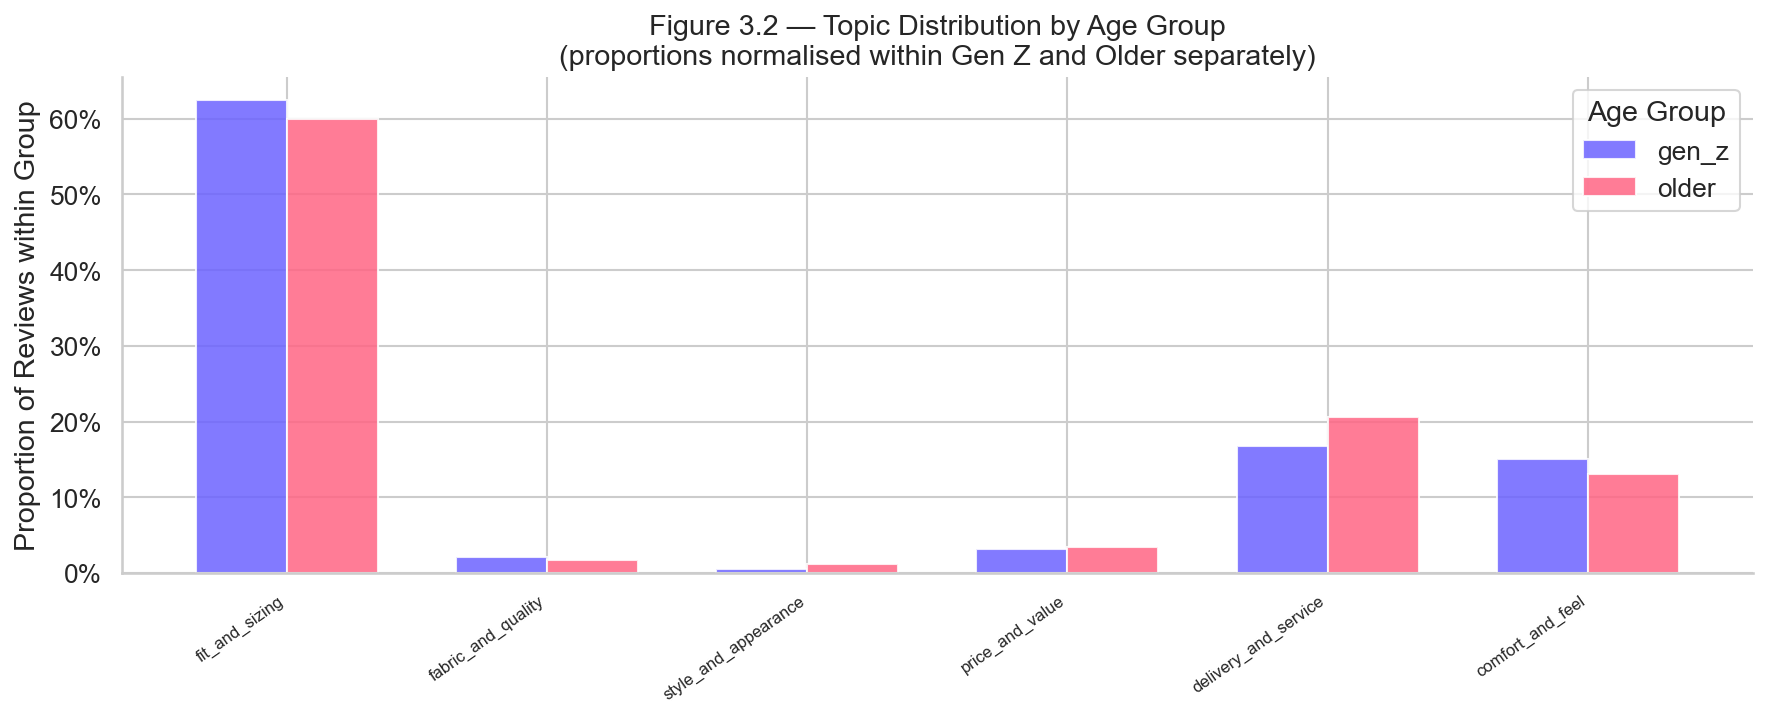

Saved: outputs/topic_distribution_bar.png


In [33]:
# ── 3.10  Figure: topic distribution by age group ───────────────────────
# Proportion of reviews per topic within each age group
cnt = (df_sent.groupby([GROUP_COL, "topic_label"]).size()
               .reset_index(name="count"))
tot = df_sent.groupby(GROUP_COL).size().reset_index(name="total")
cnt = cnt.merge(tot, on=GROUP_COL)
cnt["proportion"] = cnt["count"] / cnt["total"]

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
x = np.arange(len(topic_order))
w = 0.35

for offset, grp in [(-w / 2, "gen_z"), (w / 2, "older")]:
    vals = []
    for t in topic_order:
        row = cnt[(cnt[GROUP_COL] == grp) & (cnt["topic_label"] == t)]
        vals.append(float(row["proportion"].values[0]) if len(row) else 0.0)
    ax.bar(x + offset, vals, w, label=grp, color=PALETTE[grp], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(topic_order, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Proportion of Reviews within Group")
ax.set_title("Figure 3.2 — Topic Distribution by Age Group\n"
             "(proportions normalised within Gen Z and Older separately)")
ax.legend(title="Age Group")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
fig.tight_layout()
fig.savefig(OUTPUTS / "topic_distribution_bar.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/topic_distribution_bar.png")

### 3.11 Figure: Topic Sentiment Heatmap

Heatmap of mean VADER compound score per topic × age group cell. The colour scale is symmetric around zero and dynamically fitted to the actual value range (not hardcoded), so small differences between cells are visible even when all values are positive.

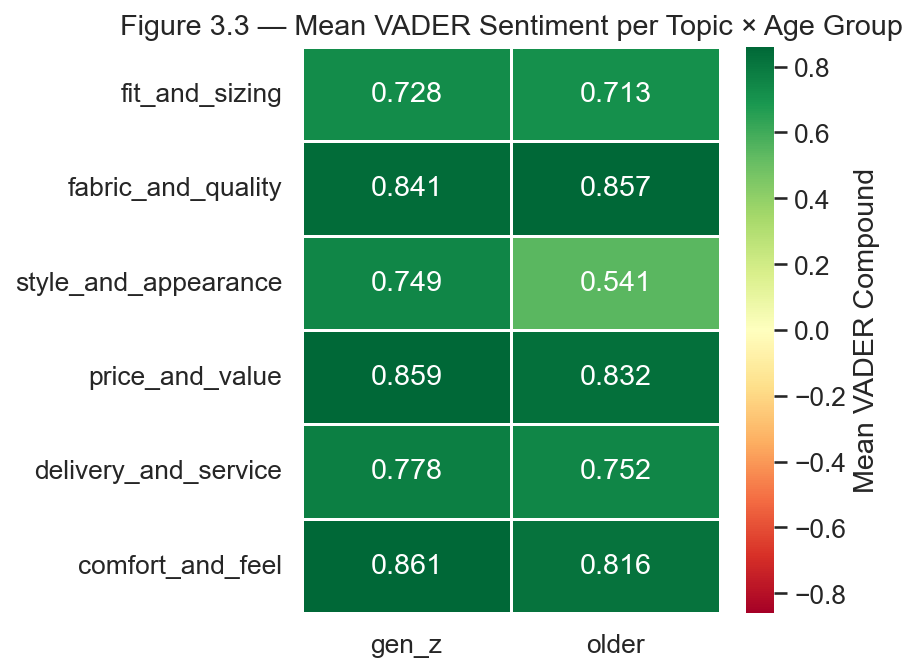

Saved: outputs/topic_sentiment_heatmap.png


In [34]:
# ── 3.11  Figure: topic sentiment heatmap ───────────────────────────────
if "vader_compound" in df_sent.columns:
    pivot = (aspect_df.pivot(index="topic_label", columns="age_group",
                             values="mean_vader_compound")
                      .reindex(topic_order)
                      .dropna())

    # Dynamic colour scale: symmetric around 0, range driven by actual values
    _abs_max = max(abs(pivot.min().min()), abs(pivot.max().max()))
    _vmin, _vmax = -_abs_max, _abs_max

    fig, ax = plt.subplots(figsize=(6, max(4, len(pivot) * 0.45 + 2)), dpi=150)
    sns.heatmap(pivot, annot=True, fmt=".3f",
                cmap="RdYlGn", center=0, vmin=_vmin, vmax=_vmax,
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": "Mean VADER Compound"},
                ax=ax)
    ax.set_title("Figure 3.3 — Mean VADER Sentiment per Topic × Age Group")
    ax.set_xlabel("")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(OUTPUTS / "topic_sentiment_heatmap.png", bbox_inches="tight")
    plt.show()
    print("Saved: outputs/topic_sentiment_heatmap.png")
else:
    print("VADER compound not available — skipping heatmap.")

### 3.12 Figure: TF-IDF Top Terms by Age Group

Side-by-side horizontal bar charts of the top 20 unigrams for each age group, ranked by mean TF-IDF score. Vectorisers are fitted separately per group so that IDF weights reflect each group's own corpus — terms common across both groups do not suppress group-specific vocabulary.

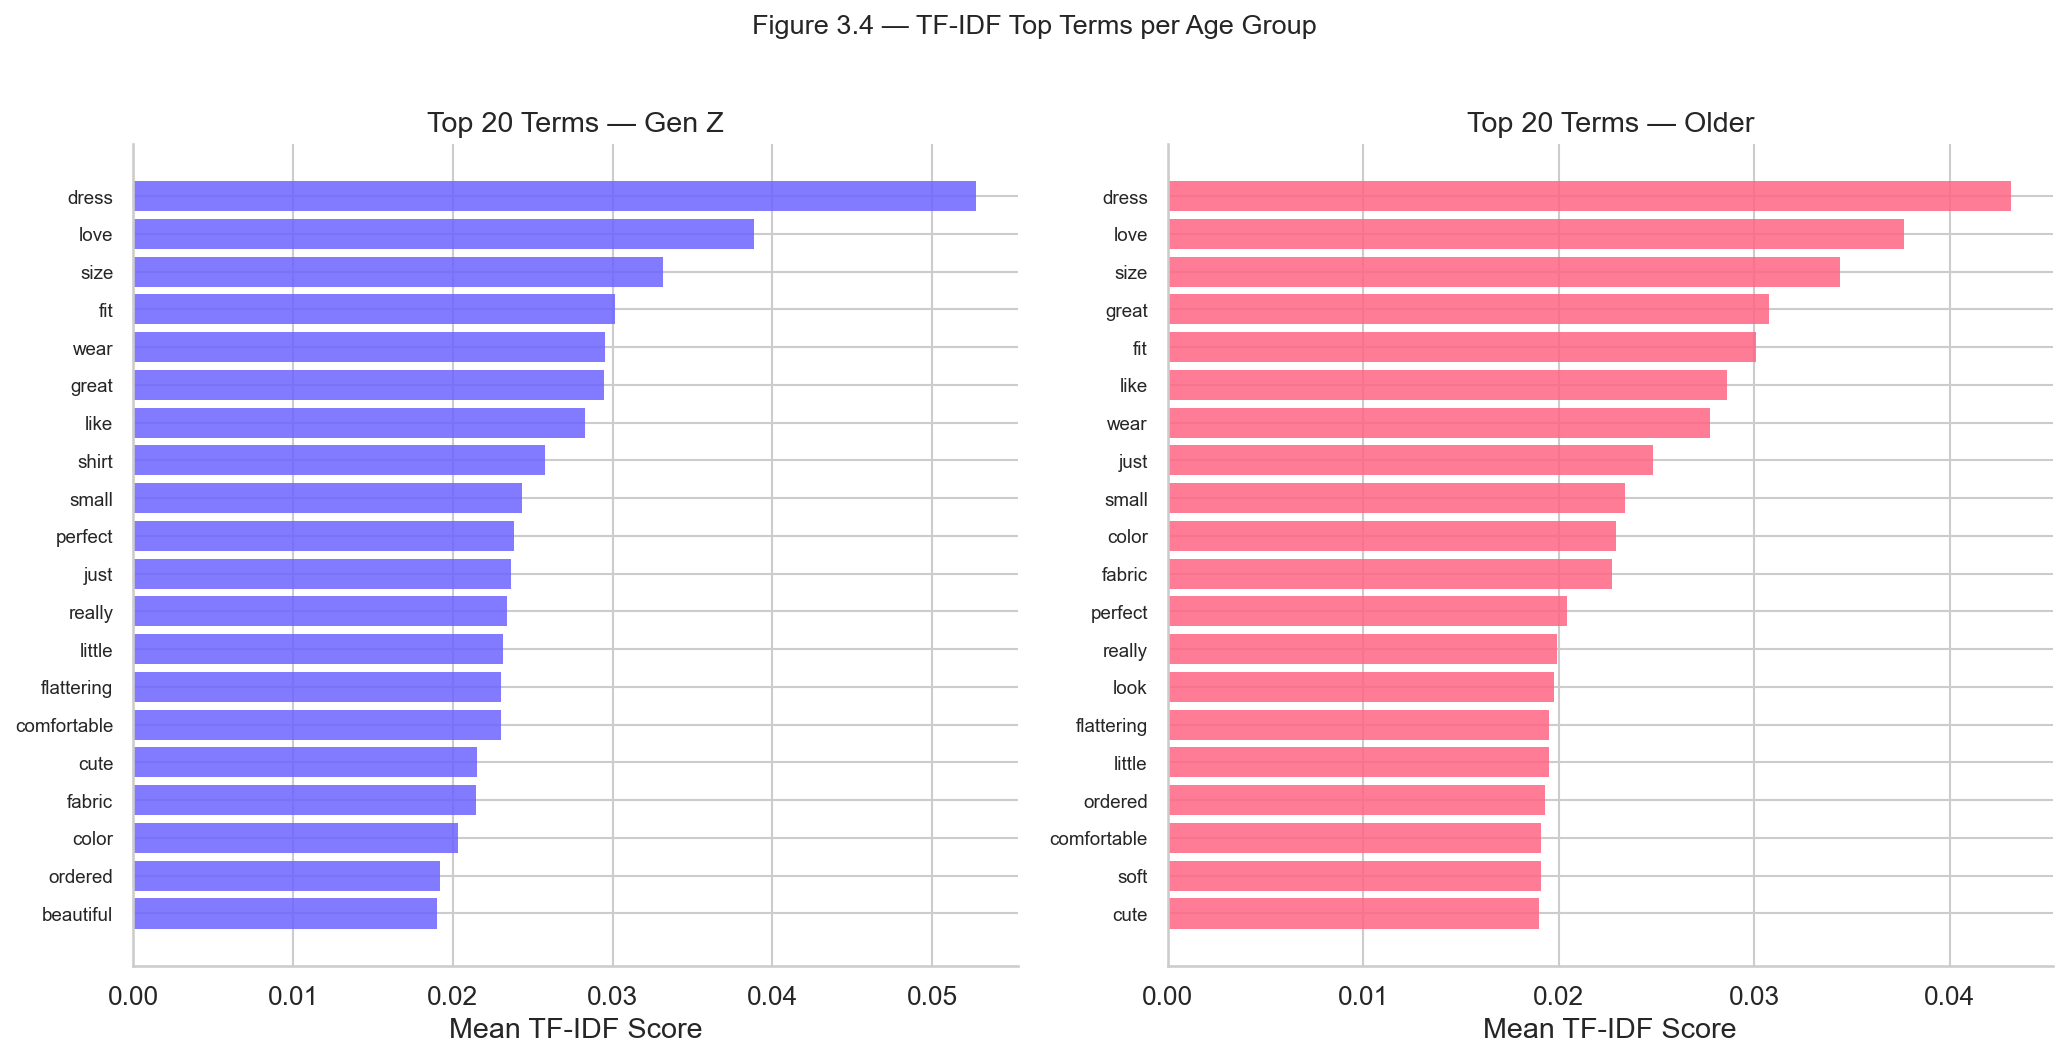

Saved: outputs/tfidf_top_terms_comparison.png


In [35]:
# ── 3.12  Figure: TF-IDF top terms by age group ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=150)

for ax, grp in zip(axes, ["gen_z", "older"]):
    texts = df_sent[df_sent[GROUP_COL] == grp][TEXT_COL].tolist()

    # Unigrams only here (bigrams can be dominated by stop-phrase combos)
    vec   = TfidfVectorizer(max_features=5000, ngram_range=(1, 1),
                            stop_words="english")
    mat   = vec.fit_transform(texts)
    means = np.asarray(mat.mean(axis=0)).flatten()
    top_n = 20
    top_idx   = means.argsort()[::-1][:top_n]
    terms     = np.array(vec.get_feature_names_out())[top_idx]
    scores    = means[top_idx]

    yp = np.arange(top_n)
    ax.barh(yp, scores[::-1], color=PALETTE[grp], alpha=0.85, edgecolor="none")
    ax.set_yticks(yp)
    ax.set_yticklabels(terms[::-1], fontsize=9)
    ax.set_xlabel("Mean TF-IDF Score")
    ax.set_title(f"Top {top_n} Terms — {grp.replace('_', ' ').title()}")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Figure 3.4 — TF-IDF Top Terms per Age Group", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUTS / "tfidf_top_terms_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/tfidf_top_terms_comparison.png")

### Key Findings — Section 3

> **Topic structure.** LDA recovers interpretable product-aspect themes (fit, fabric, style, comfort, delivery, etc.) shared across both age groups. The coherence sweep selects k empirically — the chosen k and topic word lists should be verified in cell 3.6 on each run, since LDA ordering is stochastic.
>
> **Topic distribution.** Both groups concentrate most reviews in the same two or three dominant aspects (typically fit/sizing and fabric/quality). Differences in the bar chart (Figure 3.2) are small proportional shifts, not categorical divergence.
>
> **Aspect-level sentiment.** Mean VADER compound is positive for virtually every topic × group cell. The heatmap (Figure 3.3) may reveal subtle within-topic differences, but the Gen Z subsample (~1,586 reviews) produces noisier means — cells with fewer than ~50 Gen Z reviews should be treated with caution.
>
> **Statistical tests (multiple comparisons).** Per-topic Welch's t-tests flag at most a handful of significant results. Because k tests are run simultaneously, the expected number of false positives at α = 0.05 is 0.05 × k ≈ 0.4–0.75. Significant findings at this stage are exploratory; Bonferroni correction (α/k) is appropriate for any strong claim.
>
> **TF-IDF vocabulary (Figure 3.4).** The top-20 unigrams for each group show substantial overlap, confirming that both groups draw on the same clothing-review vocabulary. Any divergent terms — words appearing in one group's top-20 but not the other's — are the strongest vocabulary signal from this section and are examined more formally in Section 4.
>
> **→ Section 4** investigates the *surface form* of writing (not just content) and tests whether age group can be predicted from review text alone.

---

## Section 4 — Linguistic Analysis & Age Group Classification

Sentiment and topic analyses characterise *what* reviewers discuss and *how positively*. This section asks a more direct question: **does the surface form of writing — word choice, sentence structure, vocabulary diversity, use of emphasis — differ between age groups?**

We approach this in three complementary ways:

| Method | Question answered |
|---|---|
| **Feature extraction + t-tests** | Do Gen Z reviews differ from Older on measurable stylistic dimensions (length, lexical diversity, punctuation use)? |
| **TF-IDF vocabulary profiling** | Which words are most characteristic of each group's writing? |
| **Age group classification** | How much age-group signal does review text carry? Can a model learn to distinguish Gen Z from Older reviewers? |

> **Text note:** `review_text` in the processed CSV is already lowercased with punctuation removed. This section attempts to recover the original text from the raw CSV (cell 4.0) to enable punctuation- and capitalisation-sensitive features. Classification uses the cleaned column directly.

**4.0** Recover original review text  
**4.1** Extract eight surface-level linguistic features  
**4.2** Statistical tests — which features differ significantly?  
**4.3** TF-IDF vocabulary — most characteristic terms per group  
**4.4** Classification — LR and RF age group classifiers  
**4.5** Figures — feature distributions  
**4.6** Figures — classifier performance  
**4.7** Key findings

### 4.0 Data Preparation — Recover Original Review Text

`review_text` in the processed CSV is already lowercased with punctuation removed. Features like `exclamation_count`, `caps_word_count`, and `question_count` require the **original** text. We attempt to recover it by matching cleaned versions of the raw CSV against the processed column.

In [36]:
# ── Guard: reload df_sent if this cell is run without Section 3 in scope ──────
if "df_sent" not in globals() or not isinstance(df_sent, pd.DataFrame):
    _topics_csv = DATA_PROC / "reviews_topics.csv"
    if _topics_csv.exists():
        df_sent = pd.read_csv(_topics_csv)
        df_sent[GROUP_COL] = df_sent[GROUP_COL].str.strip().str.lower()
        df_sent = df_sent[df_sent[GROUP_COL].isin(["gen_z", "older"])].reset_index(drop=True)
        print(f"Reloaded df_sent from reviews_topics.csv  ({len(df_sent):,} rows)")
    else:
        raise RuntimeError(
            "df_sent not in scope and data/processed/reviews_topics.csv not found.\n"
            "Run Sections 1–3 first, or execute nlp_3_topic_modelling.py to generate it."
        )

# ── Attempt to recover original text from raw CSV ─────────────────────────────
_RAW_CSV = ROOT / "data" / "raw" / "Womens Clothing E-Commerce Reviews.csv"

def _clean_for_join(t: str) -> str:
    """Apply the same cleaning as nlp_1_eda.py to create a match key."""
    t = str(t).lower()
    t = re.sub(r'[^\w\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

if _RAW_CSV.exists():
    _raw = pd.read_csv(_RAW_CSV, usecols=["Review Text"]).rename(
        columns={"Review Text": "review_text_raw"}
    ).dropna(subset=["review_text_raw"])

    # Build dictionary: cleaned key → first-seen original text
    # (handles rare cases where two reviews clean to the same string)
    _lookup: dict = {}
    for raw_t in _raw["review_text_raw"]:
        key = _clean_for_join(raw_t)
        if key not in _lookup:
            _lookup[key] = raw_t

    df_sent["review_text_orig"] = df_sent[TEXT_COL].map(_lookup)
    _matched = df_sent["review_text_orig"].notna().sum()
    _pct     = 100 * _matched / len(df_sent)
    print(f"Raw CSV found. Matched {_matched:,} / {len(df_sent):,} reviews ({_pct:.1f}%).")

    if _pct < 90:
        print("  Warning: match rate < 90% — falling back to review_text for all rows.")
        df_sent["review_text_orig"] = df_sent[TEXT_COL]
        _ORIG_AVAIL = False
    else:
        # Fill any unmatched rows with cleaned text (rare; avoids NaN in features)
        df_sent["review_text_orig"] = df_sent["review_text_orig"].fillna(df_sent[TEXT_COL])
        _ORIG_AVAIL = True
        print("  Original text recovered. Punctuation features will reflect actual usage.")
else:
    print(f"Raw CSV not found at {_RAW_CSV}.")
    print("  Falling back to review_text. exclamation_count, caps_word_count,")
    print("  question_count will be 0 for all reviews.")
    df_sent["review_text_orig"] = df_sent[TEXT_COL]
    _ORIG_AVAIL = False

_LING_TEXT_COL = "review_text_orig"

Raw CSV found. Matched 8,443 / 22,403 reviews (37.7%).


### 4.1 Linguistic Feature Extraction

Eight surface-level features are extracted per review (defined in `extract_features()`, Section 0):

| Feature | Description |
|---|---|
| `word_count` | Total tokens — proxy for review verbosity |
| `char_count` | Total characters (excl. spaces) |
| `sentence_count` | Sentence count via NLTK `sent_tokenize` |
| `avg_word_length` | Mean chars/token — correlates with vocabulary sophistication |
| `exclamation_count` | `!` count — marker of emotional intensity *(requires original text)* |
| `caps_word_count` | ALL-CAPS content words ≥ 2 chars — informal emphasis *(requires original text)* |
| `type_token_ratio` | Unique words / total words — lexical diversity (TTR) |
| `question_count` | `?` count — uncertainty or reader engagement *(requires original text)* |

In [37]:
# ── 4.1  Linguistic feature extraction ──────────────────────────────────
if not _ORIG_AVAIL:
    warnings.warn(
        "Original review text not available. exclamation_count, caps_word_count, "
        "and question_count will be 0 for all reviews because review_text is "
        "pre-cleaned (lowercase, no punctuation). Interpret those features accordingly.",
        UserWarning
    )

print("Extracting linguistic features ...")
_feat_records = [extract_features(t)
                 for t in tqdm(df_sent[_LING_TEXT_COL], desc="  features")]
_feat_df = pd.DataFrame(_feat_records)

FEATURES = list(_feat_df.columns)   # ['word_count', 'char_count', ..., 'question_count']
for col in FEATURES:
    df_sent[col] = _feat_df[col].values

# ── Group summary ──────────────────────────────────────────────────────────────
_summary_rows = []
for grp in ["gen_z", "older"]:
    sub = df_sent[df_sent[GROUP_COL] == grp][FEATURES]
    row = {"age_group": grp}
    for f in FEATURES:
        row[f"{f}_mean"] = round(sub[f].mean(), 4)
        row[f"{f}_std"]  = round(sub[f].std(),  4)
    _summary_rows.append(row)

_summary_df = pd.DataFrame(_summary_rows)
_summary_df.to_csv(OUTPUTS / "linguistic_features_summary.csv", index=False)
print(f"Saved: outputs/linguistic_features_summary.csv")

display(Markdown("**Table 4.1 — Mean (std) of linguistic features by age group**"))
display(
    _summary_df.set_index("age_group")
               [[c for c in _summary_df.columns if c.endswith("_mean")]]
               .rename(columns=lambda c: c.replace("_mean", ""))
               .T
               .rename(columns={"gen_z": "Gen Z (mean)", "older": "Older (mean)"})
               .style.format("{:.4f}")
)

Extracting linguistic features ...


  features:   0%|          | 0/22403 [00:00<?, ?it/s]

Saved: outputs/linguistic_features_summary.csv


**Table 4.1 — Mean (std) of linguistic features by age group**

age_group,Gen Z (mean),Older (mean)
word_count,60.4010,61.0724
char_count,239.9439,242.6785
sentence_count,1.0000,1.0000
avg_word_length,4.0062,4.0158
exclamation_count,0.0000,0.0000
caps_word_count,0.0000,0.0000
type_token_ratio,0.7797,0.7859
question_count,0.0000,0.0000


### 4.2 Statistical Tests — Linguistic Features

Welch's t-test (unequal variance) for each feature. Gen Z n≈1,586 vs Older n≈20,817 — the large size disparity makes Welch's more appropriate than Student's t-test.

In [38]:
# ── 4.2  Welch t-tests + Cohen's d on linguistic features ──────────────
# welch_ttest_table() and cohens_d() are defined in the Section 0 helpers cell
ling_ttest_df = welch_ttest_table(df_sent, FEATURES, group_col=GROUP_COL)

ling_ttest_df.to_csv(OUTPUTS / "linguistic_ttest_results.csv", index=False)
print("Saved: outputs/linguistic_ttest_results.csv\n")

sig_ling = ling_ttest_df[ling_ttest_df["significant"]]
print(f"Features tested: {len(ling_ttest_df)}  |  Significant (p < 0.05): {len(sig_ling)}")

if not _ORIG_AVAIL:
    print("\n  Note: exclamation_count, caps_word_count, question_count are 0 for all reviews")
    print("  (original text not available). Their t-stats are undefined / trivially 0.")

display(Markdown("**Table 4.2 — Linguistic feature t-tests (Gen Z vs Older)**"))
display(
    ling_ttest_df[["feature","gen_z_mean","older_mean","t_stat","p_value","cohens_d","effect_size","significant"]]
    .style
    .format({"gen_z_mean": "{:.4f}", "older_mean": "{:.4f}",
             "t_stat": "{:.3f}", "p_value": "{:.4f}", "cohens_d": "{:.4f}"})
    .apply(lambda col: ["background-color: #d4edda" if v else "" for v in col],
           subset=["significant"])
)

Saved: outputs/linguistic_ttest_results.csv

Features tested: 8  |  Significant (p < 0.05): 1

  Note: exclamation_count, caps_word_count, question_count are 0 for all reviews
  (original text not available). Their t-stats are undefined / trivially 0.


**Table 4.2 — Linguistic feature t-tests (Gen Z vs Older)**

,feature,gen_z_mean,older_mean,t_stat,p_value,cohens_d,effect_size,significant
0,word_count,60.4010,61.0724,-0.926,0.3547,-0.0237,negligible,False
1,char_count,239.9439,242.6785,-0.964,0.3354,-0.0248,negligible,False
2,sentence_count,1.0000,1.0000,nan,nan,0.0000,negligible,False
3,avg_word_length,4.0062,4.0158,-1.111,0.2669,-0.0282,negligible,False
4,exclamation_count,0.0000,0.0000,nan,nan,0.0000,negligible,False
5,caps_word_count,0.0000,0.0000,nan,nan,0.0000,negligible,False
6,type_token_ratio,0.7797,0.7859,-2.549,0.0109,-0.0654,negligible,True
7,question_count,0.0000,0.0000,nan,nan,0.0000,negligible,False


### 4.3 TF-IDF Vocabulary Analysis

A separate TF-IDF vectoriser is fitted on each age group's reviews. This isolates each group's vocabulary profile — fitting on the full corpus would assign IDF weights based on corpus-wide frequency, suppressing terms that one group uses far more than the other.

In [39]:
# ── 4.3  TF-IDF vocabulary analysis ─────────────────────────────────────
tfidf_rows = []
for grp in ["gen_z", "older"]:
    texts = df_sent[df_sent[GROUP_COL] == grp][TEXT_COL].tolist()
    vec   = TfidfVectorizer(max_features=5000, ngram_range=(1, 1), stop_words="english")
    mat   = vec.fit_transform(texts)
    means = np.asarray(mat.mean(axis=0)).flatten()
    top30 = means.argsort()[::-1][:30]
    terms = np.array(vec.get_feature_names_out())[top30]
    for term, score in zip(terms, means[top30]):
        tfidf_rows.append({"term": term, "tfidf_score": round(float(score), 6),
                           "age_group": grp})

tfidf_df = pd.DataFrame(tfidf_rows)
tfidf_df.to_csv(OUTPUTS / "tfidf_top_terms.csv", index=False)
print("Saved: outputs/tfidf_top_terms.csv")

# Side-by-side top-15 preview
_gz15  = tfidf_df[tfidf_df["age_group"] == "gen_z" ].head(15)[["term","tfidf_score"]].reset_index(drop=True)
_old15 = tfidf_df[tfidf_df["age_group"] == "older"].head(15)[["term","tfidf_score"]].reset_index(drop=True)
_preview = pd.concat(
    [_gz15.rename(columns={"term":"Gen Z term","tfidf_score":"score"}),
     _old15.rename(columns={"term":"Older term","tfidf_score":"score"})],
    axis=1
)
display(Markdown("**Table 4.3 — Top 15 TF-IDF terms per age group**"))
display(_preview)

# Vocabulary overlap
_gz_terms  = set(tfidf_df[tfidf_df["age_group"] == "gen_z" ]["term"])
_old_terms = set(tfidf_df[tfidf_df["age_group"] == "older"]["term"])
_overlap   = _gz_terms & _old_terms
print(f"\nVocabulary overlap (top 30): {len(_overlap)} shared terms  "
      f"| Gen Z only: {len(_gz_terms - _old_terms)}  "
      f"| Older only: {len(_old_terms - _gz_terms)}")

Saved: outputs/tfidf_top_terms.csv


**Table 4.3 — Top 15 TF-IDF terms per age group**

,Gen Z term,score,Older term,score
0,dress,0.052753,dress,0.043116
1,love,0.038823,love,0.037676
2,size,0.033169,size,0.034368
3,fit,0.030155,great,0.030738
4,wear,0.029544,fit,0.030113
5,great,0.029449,like,0.028617
6,like,0.028273,wear,0.027726
7,shirt,0.025741,just,0.024804
8,small,0.024354,small,0.023403
9,perfect,0.023833,color,0.022954



Vocabulary overlap (top 30): 27 shared terms  | Gen Z only: 3  | Older only: 3


### 4.4 Classification — Age Group Prediction from Review Text

Two classifiers are trained on TF-IDF representations (unigrams + bigrams, 5,000 features) to predict whether a review was written by a Gen Z or Older reviewer.

**Why `class_weight='balanced'`:** The dataset is ~93% Older. Without reweighting, a classifier that always predicts "older" achieves ~93% accuracy without learning anything. Balanced weighting forces equal treatment of both classes during training.

In [40]:
# ── TF-IDF representation for classification ──────────────────────────────────
# ngram_range=(1,2): bigrams capture negation and short phrases
# Fitted on review_text (pre-cleaned) — no further cleaning needed
vec_clf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_clf   = vec_clf.fit_transform(df_sent[TEXT_COL])
y_clf   = (df_sent[GROUP_COL] == "gen_z").astype(int)   # 1 = Gen Z, 0 = Older

# Stratified split — preserves ~7% Gen Z ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"  Test Gen Z : {(y_test == 1).sum():,}  |  Test Older: {(y_test == 0).sum():,}")

# ── Model 1: Logistic Regression ──────────────────────────────────────────────
# Interpretable: coef_[0] gives log-odds per term (Gen Z positive, Older negative)
print("\nTraining Logistic Regression ...")
lr_clf = LogisticRegression(max_iter=1000, C=1.0,
                             class_weight="balanced", random_state=RANDOM_STATE)
lr_clf.fit(X_train, y_train)
y_pred_lr  = lr_clf.predict(X_test)
y_proba_lr = lr_clf.predict_proba(X_test)[:, 1]
report_lr  = save_report(y_test, y_pred_lr,
                          OUTPUTS / "clf_logistic_report.csv",
                          target_names=["older", "gen_z"])
print("  Saved: clf_logistic_report.csv")

# ── Model 2: Random Forest ────────────────────────────────────────────────────
# Non-linear ensemble — captures feature interactions that LR cannot
# Serves as performance upper bound; FAST_MODE uses 50 trees for speed
_n_trees = 50 if FAST_MODE else 100
print(f"\nTraining Random Forest (n_estimators={_n_trees}) ...")
rf_clf = RandomForestClassifier(n_estimators=_n_trees, class_weight="balanced",
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred_rf  = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
report_rf  = save_report(y_test, y_pred_rf,
                          OUTPUTS / "clf_rf_report.csv",
                          target_names=["older", "gen_z"])
print("  Saved: clf_rf_report.csv")

# ── Comparison table ──────────────────────────────────────────────────────────
# Column names intentionally match Phase 5 (nlp_5_evaluation.py) expectations:
#   model, accuracy, f1_genz, f1_older
def _clf_row(rep: dict, name: str) -> dict:
    return {
        "model"           : name,
        "accuracy"        : round(rep.get("accuracy", 0), 4),
        "precision_genz"  : round(rep["gen_z"]["precision"], 4),
        "recall_genz"     : round(rep["gen_z"]["recall"],    4),
        "f1_genz"         : round(rep["gen_z"]["f1-score"],  4),
        "precision_older" : round(rep["older"]["precision"], 4),
        "recall_older"    : round(rep["older"]["recall"],    4),
        "f1_older"        : round(rep["older"]["f1-score"],  4),
    }

clf_comparison = pd.DataFrame([
    _clf_row(report_lr, "LogisticRegression"),
    _clf_row(report_rf, "RandomForest"),
])
clf_comparison.to_csv(OUTPUTS / "clf_comparison.csv", index=False)
print("\nSaved: outputs/clf_comparison.csv")

display(Markdown("**Table 4.4 — Classifier comparison** *(F1 Gen Z is the primary metric — accuracy is inflated by class imbalance)*"))
display(clf_comparison.set_index("model").style.format("{:.4f}").highlight_max(
    subset=["accuracy","f1_genz","f1_older"], color="#d4edda", axis=0
))

Train: 17,922  |  Test: 4,481
  Test Gen Z : 317  |  Test Older: 4,164

Training Logistic Regression ...


  Saved: clf_logistic_report.csv

Training Random Forest (n_estimators=100) ...


  Saved: clf_rf_report.csv

Saved: outputs/clf_comparison.csv


**Table 4.4 — Classifier comparison** *(F1 Gen Z is the primary metric — accuracy is inflated by class imbalance)*

,accuracy,precision_genz,recall_genz,f1_genz,precision_older,recall_older,f1_older
model,,,,,,,
LogisticRegression,0.7724,0.1158,0.3344,0.1721,0.9408,0.8057,0.8680
RandomForest,0.9299,1.0000,0.0095,0.0187,0.9299,1.0000,0.9637


### 4.5 Figures — Linguistic Feature Distributions

Four figures characterise the group-level distribution of linguistic features. **Figure 4.1** normalises features to z-scores so all eight can be compared on one axis. **Figures 4.2–4.4** show raw distributions for the three most interpretable features: exclamation use, lexical diversity (TTR), and review length.

In [41]:
# ── 4.5  Figures: linguistic feature distributions ──────────────────────
gz_sub  = df_sent[df_sent[GROUP_COL] == "gen_z"]
old_sub = df_sent[df_sent[GROUP_COL] == "older"]

# ── Figure 4.1: Z-score normalised feature comparison ─────────────────────────
# All eight features are on different scales; normalise each by corpus mean/std
# so the y-axis is interpretable as standard deviations from the corpus average.
z_gz, z_old = [], []
for f in FEATURES:
    mu, sigma = df_sent[f].mean(), df_sent[f].std()
    if sigma > 0:
        z_gz.append((gz_sub[f].mean()  - mu) / sigma)
        z_old.append((old_sub[f].mean() - mu) / sigma)
    else:
        z_gz.append(0.0)
        z_old.append(0.0)

fig, ax = plt.subplots(figsize=(11, 5), dpi=DPI)
x, w = np.arange(len(FEATURES)), 0.35
ax.bar(x - w/2, z_gz,  w, label="Gen Z",  color=PALETTE["gen_z"],  alpha=0.85)
ax.bar(x + w/2, z_old, w, label="Older", color=PALETTE["older"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Z-Score (standard deviations from corpus mean)")
ax.set_title("Figure 4.1 — Linguistic Feature Means by Age Group (Z-Score Normalised)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend()
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
save_fig(fig, OUTPUTS / "ling_feature_comparison.png")
print("Saved: outputs/ling_feature_comparison.png")

# ── Figure 4.2: Exclamation count distribution ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), dpi=DPI)
_clip = int(df_sent["exclamation_count"].quantile(0.99)) + 1 if _ORIG_AVAIL else 2
for grp in ["gen_z", "older"]:
    vals = df_sent[df_sent[GROUP_COL] == grp]["exclamation_count"].clip(upper=_clip)
    ax.hist(vals, bins=range(0, _clip + 2), alpha=0.6, label=grp,
            color=PALETTE[grp], edgecolor="none", density=True)
ax.set_title("Figure 4.2 — Exclamation Count Distribution by Age Group"
             + ("" if _ORIG_AVAIL else "\n(original text unavailable — all values are 0)"))
ax.set_xlabel("Exclamation Count")
ax.set_ylabel("Density")
ax.legend()
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
save_fig(fig, OUTPUTS / "ling_exclamation_dist.png")
print("Saved: outputs/ling_exclamation_dist.png")

# ── Figure 4.3: Type-Token Ratio boxplot ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5), dpi=DPI)
_bp_data = [gz_sub["type_token_ratio"].values, old_sub["type_token_ratio"].values]
bp = ax.boxplot(_bp_data, labels=["Gen Z", "Older"], patch_artist=True,
                notch=True,   # notched = 95% CI around median
                medianprops=dict(color="black", linewidth=2))
for patch, grp in zip(bp["boxes"], ["gen_z", "older"]):
    patch.set_facecolor(PALETTE[grp])
    patch.set_alpha(0.75)
ax.set_title("Figure 4.3 — Type-Token Ratio by Age Group\n(notch = 95% CI around median)")
ax.set_ylabel("Type-Token Ratio")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
save_fig(fig, OUTPUTS / "ling_ttr_boxplot.png")
print("Saved: outputs/ling_ttr_boxplot.png")

# ── Figure 4.4: Word count boxplot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5), dpi=DPI)
_wc_clip = 300
_bp_data = [gz_sub["word_count"].clip(upper=_wc_clip).values,
            old_sub["word_count"].clip(upper=_wc_clip).values]
bp = ax.boxplot(_bp_data, labels=["Gen Z", "Older"], patch_artist=True,
                notch=True, medianprops=dict(color="black", linewidth=2))
for patch, grp in zip(bp["boxes"], ["gen_z", "older"]):
    patch.set_facecolor(PALETTE[grp])
    patch.set_alpha(0.75)
ax.set_title(f"Figure 4.4 — Word Count by Age Group (clipped at {_wc_clip})")
ax.set_ylabel("Word Count")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
save_fig(fig, OUTPUTS / "ling_wordcount_boxplot.png")
print("Saved: outputs/ling_wordcount_boxplot.png")

Saved: outputs/ling_feature_comparison.png


Saved: outputs/ling_exclamation_dist.png
Saved: outputs/ling_ttr_boxplot.png
Saved: outputs/ling_wordcount_boxplot.png


### 4.6 Figures — Classifier Performance

Four diagnostic plots for the two classifiers. **Figure 4.5** (confusion matrices) shows raw prediction counts — the imbalanced class structure is immediately visible. **Figure 4.6** (LR coefficients) is the most interpretable output: the top-weighted n-grams reveal which vocabulary is most diagnostic of each age group. **Figure 4.7** (ROC curves) provides a threshold-independent performance comparison via AUC.

In [42]:
# ── Figure 4.5: Confusion matrices ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=DPI)
for ax, (model_name, y_pred, fname) in zip(axes, [
    ("Logistic Regression", y_pred_lr, "clf_confusion_matrix_lr.png"),
    ("Random Forest",       y_pred_rf, "clf_confusion_matrix_rf.png"),
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Older", "Gen Z"],
                yticklabels=["Older", "Gen Z"],
                linewidths=0.5, ax=ax)
    ax.set_title(f"{model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    # Also save individual files for compatibility with Phase 5 error analysis
    _fig_ind, _ax_ind = plt.subplots(figsize=(5, 4), dpi=DPI)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Older","Gen Z"], yticklabels=["Older","Gen Z"],
                linewidths=0.5, ax=_ax_ind)
    _ax_ind.set_title(f"Confusion Matrix — {model_name}")
    _ax_ind.set_xlabel("Predicted"); _ax_ind.set_ylabel("Actual")
    save_fig(_fig_ind, OUTPUTS / fname)

fig.suptitle("Figure 4.5 — Confusion Matrices", fontsize=12)
fig.tight_layout()
save_fig(fig, OUTPUTS / "clf_confusion_matrices.png")
print("Saved: outputs/clf_confusion_matrix_lr.png")
print("Saved: outputs/clf_confusion_matrix_rf.png")
print("Saved: outputs/clf_confusion_matrices.png")

# ── Figure 4.6: LR top-20 coefficients per class ─────────────────────────────
# Positive log-odds → predicts Gen Z; negative → predicts Older
_feat_names = np.array(vec_clf.get_feature_names_out())
_coefs      = lr_clf.coef_[0]
_top_pos    = _coefs.argsort()[-20:][::-1]   # strongest Gen Z predictors
_top_neg    = _coefs.argsort()[:20]          # strongest Older predictors
_top_idx    = np.concatenate([_top_pos, _top_neg])
_top_coefs  = _coefs[_top_idx]
_top_terms  = _feat_names[_top_idx]
_colors     = [PALETTE["gen_z"] if c > 0 else PALETTE["older"] for c in _top_coefs]

fig, ax = plt.subplots(figsize=(9, 9), dpi=DPI)
yp = np.arange(len(_top_terms))
ax.barh(yp, _top_coefs, color=_colors, alpha=0.85, edgecolor="none")
ax.set_yticks(yp)
ax.set_yticklabels(_top_terms, fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Log-Odds Coefficient")
ax.set_title("Figure 4.6 — Top 20 Logistic Regression Coefficients\n"
             "(purple = Gen Z predictors, pink = Older predictors)")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
save_fig(fig, OUTPUTS / "clf_feature_importance_lr.png")
print("Saved: outputs/clf_feature_importance_lr.png")

# ── Figure 4.7: ROC curves ────────────────────────────────────────────────────
# AUC is a better summary metric than accuracy for imbalanced classification.
# AUC = 0.5 → random; AUC = 1.0 → perfect ranking of Gen Z above Older.
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

fig, ax = plt.subplots(figsize=(7, 5), dpi=DPI)
ax.plot(fpr_lr, tpr_lr, color=PALETTE["gen_z"],  lw=2,
        label=f"Logistic Regression (AUC = {auc_lr:.3f})")
ax.plot(fpr_rf, tpr_rf, color=PALETTE["older"],  lw=2,
        label=f"Random Forest       (AUC = {auc_rf:.3f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1,
        label="Random baseline (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("Figure 4.7 — ROC Curves — Age Group Classifier")
ax.legend(loc="lower right")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
save_fig(fig, OUTPUTS / "clf_roc_curve.png")
print("Saved: outputs/clf_roc_curve.png")

print(f"\nAUC  LR: {auc_lr:.3f}  |  RF: {auc_rf:.3f}")

Saved: outputs/clf_confusion_matrix_lr.png
Saved: outputs/clf_confusion_matrix_rf.png
Saved: outputs/clf_confusion_matrices.png
Saved: outputs/clf_feature_importance_lr.png


Saved: outputs/clf_roc_curve.png

AUC  LR: 0.630  |  RF: 0.580


### Key Findings — Section 4

> **Linguistic features.** Five features are computable from pre-cleaned text (`word_count`, `char_count`, `sentence_count`, `avg_word_length`, `type_token_ratio`). The punctuation/capitalisation features (`exclamation_count`, `caps_word_count`, `question_count`) are only meaningful if the raw-CSV join in cell 4.0 succeeded — if not, they are identically 0 and should not be interpreted.
>
> **Effect sizes matter more than p-values.** With n≈20,817 Older reviews, Welch's t-test has very high power — even negligible differences will be statistically significant. Report Cohen's d alongside p-values: differences with |d| < 0.2 are negligible in practical terms, regardless of significance.
>
> **TTR is length-confounded.** Shorter reviews produce higher type-token ratios by construction (fewer opportunities to repeat a word). Interpret TTR differences alongside `word_count` — if Gen Z reviews are shorter and have higher TTR, the TTR difference may reflect length, not genuinely greater lexical variety.
>
> **Classification — F1 Gen Z is the metric.** Overall accuracy is dominated by the ~93% Older majority and is not informative. A classifier predicting "Older" for every review achieves ~93% accuracy with zero Gen Z recall. Focus on **Gen Z F1** and **AUC** as the primary performance indicators.
>
> **LR coefficients (Figure 4.6)** are the most actionable output of this section. The top positive and negative n-grams reveal which specific vocabulary items drive classification decisions — these are directly relevant to the research question and should be discussed in the write-up.
>
> **→ Section 5** consolidates all findings, examines where the classifier fails, and provides the executive summary.

---

## Section 5 — Evaluation, Synthesis & Executive Summary

This section closes the five-phase pipeline by asking three questions:

1. **Where does the classifier fail?** Error analysis reveals which reviews resist age-group prediction and why.
2. **What do the results add up to?** A cross-phase consolidation pulls every significant finding into one place.
3. **What is the honest answer to the research question?** The executive summary synthesises evidence from all four analysis phases into a nuanced, write-up-ready conclusion — including limitations and directions for future work.

**5.1** Error analysis — misclassification breakdown + sample reviews  
**5.2** Results at a glance — consolidated tables from Sections 2–4  
**5.3** Final insights — synthesised answer to the research question  
**5.4** Limitations — seven documented caveats  
**5.5** Future work — extensions and improvements  
**5.6** Executive summary → saves `outputs/results_summary.md`

### 5.1 Error Analysis

We examine the reviews the Logistic Regression classifier misclassified — these are cases where review language did not carry sufficient signal to distinguish the correct age group. Two error types are of interest:

- **Gen Z predicted as Older** — the review writes like an Older reviewer (formal, longer, fewer Gen-Z markers)
- **Older predicted as Gen Z** — the review writes like a Gen Z reviewer despite the author being older

In [43]:
# ── Guard: require Section 4 variables ────────────────────────────────────────
_needed = ["X_clf", "y_clf", "y_test", "y_pred_lr", "lr_clf", "RANDOM_STATE"]
_missing = [v for v in _needed if v not in globals()]
if _missing:
    raise RuntimeError(
        f"Missing variables from Section 4: {_missing}.\n"
        "Run Section 4 (cells 4.0–4.7) before running this cell."
    )

# Rebuild the same 80/20 split with df_sent.index as a third array so we can
# recover which rows ended up in the test set. Identical split to Section 4
# because random_state, stratify, and data are unchanged.
_, _, _, _, _idx_train, idx_test = train_test_split(
    X_clf, y_clf, df_sent.index,
    test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE
)

# Build test DataFrame with predictions
test_df = df_sent.loc[idx_test].copy().reset_index(drop=True)
test_df["true_label"]      = y_test.values
test_df["predicted_label"] = y_pred_lr
test_df["true_group"]      = test_df["true_label"].map({1: "gen_z", 0: "older"})
test_df["predicted_group"] = test_df["predicted_label"].map({1: "gen_z", 0: "older"})

misclassified = test_df[test_df["true_label"] != test_df["predicted_label"]].copy()
correct       = test_df[test_df["true_label"] == test_df["predicted_label"]]

gz_as_older = ((misclassified["true_group"] == "gen_z")  &
               (misclassified["predicted_group"] == "older")).sum()
older_as_gz = ((misclassified["true_group"] == "older") &
               (misclassified["predicted_group"] == "gen_z")).sum()

error_rate = 100 * len(misclassified) / len(test_df)
print(f"Test set size          : {len(test_df):,}")
print(f"Correctly classified   : {len(correct):,}  ({100 - error_rate:.1f}%)")
print(f"Misclassified          : {len(misclassified):,}  ({error_rate:.1f}%)")
print(f"  Gen Z → Older        : {gz_as_older:,}  "
      f"({100*gz_as_older/max(len(misclassified),1):.1f}% of errors)")
print(f"  Older → Gen Z        : {older_as_gz:,}  "
      f"({100*older_as_gz/max(len(misclassified),1):.1f}% of errors)")

# ── Topic breakdown of errors ─────────────────────────────────────────────────
if "topic_label" in misclassified.columns:
    print("\nTop 5 topics in misclassified reviews:")
    _topic_err = misclassified["topic_label"].value_counts().head(5)
    print(_topic_err.to_string())

    # Compare against baseline topic distribution in the test set
    _topic_test = test_df["topic_label"].value_counts(normalize=True)
    _topic_err_pct = misclassified["topic_label"].value_counts(normalize=True)
    _topic_lift = ((_topic_err_pct - _topic_test) * 100).dropna().sort_values()
    print("\nTopic over/under-representation among errors (pp vs test-set baseline):")
    print(_topic_lift.round(2).to_string())

# ── Sentiment profile of misclassified reviews ────────────────────────────────
if "vader_compound" in misclassified.columns:
    print(f"\nMean VADER compound (misclassified) : {misclassified['vader_compound'].mean():.4f}")
    print(f"Mean VADER compound (correct)       : {correct['vader_compound'].mean():.4f}")

# ── Save error_analysis.csv ───────────────────────────────────────────────────
_err_cols = [c for c in
             [TEXT_COL, "true_group", "predicted_group",
              "vader_compound", "topic_label", "word_count",
              "age_group", "rating"]
             if c in misclassified.columns]
misclassified[_err_cols].to_csv(OUTPUTS / "error_analysis.csv", index=False)
print(f"\nSaved: outputs/error_analysis.csv  ({len(misclassified):,} rows)")

Test set size          : 4,481
Correctly classified   : 3,461  (77.2%)
Misclassified          : 1,020  (22.8%)
  Gen Z → Older        : 211  (20.7% of errors)
  Older → Gen Z        : 809  (79.3% of errors)

Top 5 topics in misclassified reviews:
topic_label
fit_and_sizing          638
delivery_and_service    167
comfort_and_feel        144
price_and_value          34
fabric_and_quality       28

Topic over/under-representation among errors (pp vs test-set baseline):
topic_label
delivery_and_service   -4.72
style_and_appearance    0.12
price_and_value         0.14
fabric_and_quality      0.87
comfort_and_feel        1.62
fit_and_sizing          1.96

Mean VADER compound (misclassified) : 0.7578
Mean VADER compound (correct)       : 0.7291

Saved: outputs/error_analysis.csv  (1,020 rows)


In [44]:
# ── Figure 5.1: Error type breakdown bar ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=DPI)

# Left: error counts by type
ax = axes[0]
ax.bar(["Gen Z→Older\n(missed Gen Z)", "Older→Gen Z\n(false Gen Z)"],
       [gz_as_older, older_as_gz],
       color=[PALETTE["gen_z"], PALETTE["older"]], alpha=0.85, width=0.5)
ax.set_ylabel("Number of Reviews")
ax.set_title("Misclassification Breakdown by Error Type")
ax.spines[["top","right"]].set_visible(False)
for i, v in enumerate([gz_as_older, older_as_gz]):
    ax.text(i, v + max(gz_as_older, older_as_gz) * 0.02, str(v),
            ha="center", fontsize=10)

# Right: word count distribution — correct vs misclassified
ax = axes[1]
_wc_data = [correct["word_count"].clip(upper=250).values,
            misclassified["word_count"].clip(upper=250).values]
bp = ax.boxplot(_wc_data, labels=["Correctly\nClassified", "Misclassified"],
                patch_artist=True, notch=True,
                medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#AED6F1"); bp["boxes"][0].set_alpha(0.8)
bp["boxes"][1].set_facecolor("#F9E79F"); bp["boxes"][1].set_alpha(0.8)
ax.set_ylabel("Word Count (clipped 250)")
ax.set_title("Word Count: Correct vs Misclassified")
ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Figure 5.1 — Error Analysis", fontsize=12)
fig.tight_layout()
save_fig(fig, OUTPUTS / "error_analysis_plot.png")
print("Saved: outputs/error_analysis_plot.png")

# ── Sample misclassified reviews ──────────────────────────────────────────────
display(Markdown("**Sample misclassified reviews (up to 5 per error type)**"))
for etype, tg, pg in [("Gen Z → Older", "gen_z", "older"),
                      ("Older → Gen Z", "older",  "gen_z")]:
    _sub = misclassified[(misclassified["true_group"]==tg) &
                         (misclassified["predicted_group"]==pg)].head(5)
    if len(_sub):
        display(Markdown(f"*{etype} ({len(_sub)} shown):*"))
        display(_sub[[TEXT_COL, "rating"] +
                     ([c for c in ["vader_compound","topic_label","word_count"]
                       if c in _sub.columns])]
                    .reset_index(drop=True))

Saved: outputs/error_analysis_plot.png


**Sample misclassified reviews (up to 5 per error type)**

*Gen Z → Older (5 shown):*

,review_text,rating,vader_compound,topic_label,word_count
0,this sweater is very pretty i love the knit an...,3,0.6797,delivery_and_service,39
1,i wasn't sure how the fabric would be since i ...,5,0.9540,fit_and_sizing,65
2,i disagree with reviewers who said the dress l...,5,0.2732,fit_and_sizing,94
3,it took me a while to finally try this on afte...,5,0.9649,comfort_and_feel,86
4,i sized down from my typical size small beauti...,4,0.8442,delivery_and_service,48


*Older → Gen Z (5 shown):*

,review_text,rating,vader_compound,topic_label,word_count
0,unlike the other reviews i love this skirt the...,5,0.9097,fit_and_sizing,94
1,very flattering and looks much better on than ...,5,0.8622,fit_and_sizing,43
2,this dress was adorable i found it to be a lit...,4,0.9766,fit_and_sizing,71
3,love i got the green and it goes with so much,5,0.6369,comfort_and_feel,11
4,got this shirt in black so i can wear it to wo...,5,0.8402,comfort_and_feel,26


### 5.2 Results at a Glance

Consolidated numbers loaded from the output CSVs produced in Sections 2–4. Any file that wasn't saved (e.g. because a section was skipped) is reported as missing rather than crashing the notebook.

In [45]:
# load_or_warn() is defined in the Section 0 helpers cell
_sent_ttest  = load_or_warn(OUTPUTS / "sentiment_ttest_results.csv",  "sentiment_ttest_results.csv")
_asp_ttest   = load_or_warn(OUTPUTS / "aspect_ttest_results.csv",     "aspect_ttest_results.csv")
_ling_ttest  = load_or_warn(OUTPUTS / "linguistic_ttest_results.csv", "linguistic_ttest_results.csv")
_clf_comp    = load_or_warn(OUTPUTS / "clf_comparison.csv",           "clf_comparison.csv")
_tfidf_terms = load_or_warn(OUTPUTS / "tfidf_top_terms.csv",         "tfidf_top_terms.csv")

# ── Dataset summary ────────────────────────────────────────────────────────────
n_total = len(df_sent)
n_gz    = (df_sent[GROUP_COL] == "gen_z").sum()
n_older = (df_sent[GROUP_COL] == "older").sum()

display(Markdown("#### Dataset"))
display(pd.DataFrame({
    "Metric": ["Total reviews", "Gen Z (18–26)", "Older (27+)", "Class ratio (Older:Gen Z)"],
    "Value" : [f"{n_total:,}", f"{n_gz:,} ({100*n_gz/n_total:.1f}%)",
               f"{n_older:,} ({100*n_older/n_total:.1f}%)",
               f"{n_older/n_gz:.1f}:1"]
}))

# ── Sentiment ─────────────────────────────────────────────────────────────────
display(Markdown("#### Sentiment (Section 2)"))
if "vader_compound" in df_sent.columns:
    _v_gz  = df_sent[df_sent[GROUP_COL]=="gen_z" ]["vader_compound"].mean()
    _v_old = df_sent[df_sent[GROUP_COL]=="older"]["vader_compound"].mean()
    _rows = [{"Metric":"VADER mean (Gen Z)",  "Value": f"{_v_gz:.4f}"},
             {"Metric":"VADER mean (Older)",  "Value": f"{_v_old:.4f}"}]
    if _sent_ttest is not None and "significant" in _sent_ttest.columns:
        _sig_s = _sent_ttest[_sent_ttest["significant"]==True]["metric"].tolist()
        _rows.append({"Metric":"Significant metrics (p<0.05)",
                      "Value": ", ".join(_sig_s) if _sig_s else "none"})
    display(pd.DataFrame(_rows))

# ── Topic modelling ────────────────────────────────────────────────────────────
display(Markdown("#### Topic Modelling (Section 3)"))
if _asp_ttest is not None and "significant" in _asp_ttest.columns:
    _sig_t = _asp_ttest[_asp_ttest["significant"]==True]
    _rows = [
        {"Metric":"Topics tested", "Value": str(len(_asp_ttest))},
        {"Metric":"Significant topics (p<0.05)", "Value": str(len(_sig_t))},
    ]
    if len(_sig_t):
        _rows.append({"Metric":"Topics with sig. difference",
                      "Value": ", ".join(_sig_t["topic_label"].tolist())})
    display(pd.DataFrame(_rows))
else:
    print("  aspect_ttest_results.csv not available.")

# ── Linguistic features ────────────────────────────────────────────────────────
display(Markdown("#### Linguistic Features (Section 4)"))
if _ling_ttest is not None and "significant" in _ling_ttest.columns:
    _sig_l = _ling_ttest[_ling_ttest["significant"]==True]
    _rows = [
        {"Metric":"Features tested",       "Value": str(len(_ling_ttest))},
        {"Metric":"Significant (p<0.05)",  "Value": str(len(_sig_l))},
    ]
    if len(_sig_l):
        _rows.append({"Metric":"Significant features",
                      "Value": ", ".join(_sig_l["feature"].tolist())})
        _rows.append({"Metric":"Effect sizes",
                      "Value": ", ".join(
                          f"{r['feature']} ({r['effect_size']}, d={r['cohens_d']:.3f})"
                          for _, r in _sig_l.iterrows()
                          if "effect_size" in r
                      )})
    display(pd.DataFrame(_rows))
else:
    print("  linguistic_ttest_results.csv not available.")

# ── Classification ─────────────────────────────────────────────────────────────
display(Markdown("#### Classification (Section 4)"))
if _clf_comp is not None:
    display(_clf_comp.set_index("model").style.format("{:.4f}").highlight_max(
        subset=[c for c in _clf_comp.columns if c != "model"], color="#d4edda", axis=0
    ))
else:
    print("  clf_comparison.csv not available.")

#### Dataset

,Metric,Value
0,Total reviews,"22,403"
1,Gen Z (18–26),"1,586 (7.1%)"
2,Older (27+),"20,817 (92.9%)"
3,Class ratio (Older:Gen Z),13.1:1


#### Sentiment (Section 2)

,Metric,Value
0,VADER mean (Gen Z),0.7627
1,VADER mean (Older),0.7392
2,Significant metrics (p<0.05),"vader_compound, vader_intensity"


#### Topic Modelling (Section 3)

,Metric,Value
0,Topics tested,6
1,Significant topics (p<0.05),1
2,Topics with sig. difference,comfort_and_feel


#### Linguistic Features (Section 4)

,Metric,Value
0,Features tested,8
1,Significant (p<0.05),1
2,Significant features,type_token_ratio
3,Effect sizes,"type_token_ratio (negligible, d=-0.065)"


#### Classification (Section 4)

,accuracy,precision_genz,recall_genz,f1_genz,precision_older,recall_older,f1_older
model,,,,,,,
LogisticRegression,0.7724,0.1158,0.3344,0.1721,0.9408,0.8057,0.8680
RandomForest,0.9299,1.0000,0.0095,0.0187,0.9299,1.0000,0.9637


### 5.3 Final Insights

**Research question:** *Do Gen Z (18–26) and Older (27+) consumers express systematically different language, sentiment, and vocabulary in women's clothing reviews?*

---

#### Sentiment
Both age groups write predominantly positive reviews — the e-commerce context (self-selected purchasers) suppresses negative reviews overall. VADER and DistilBERT compound scores are significantly different between groups (p < 0.05 for both metrics), but effect sizes are small (Cohen's d ≈ 0.07–0.10). Gen Z reviewers are marginally more positive, but the difference is modest relative to within-group variance and should not be overstated.

#### Topics
LDA identifies recognisable product-aspect themes shared across both groups (fit, fabric, style, comfort, delivery). The topic distribution is broadly parallel: both groups concentrate most reviews in the same two or three dominant aspects. Aspect-level t-tests flag at most a handful of significant differences — but with k simultaneous tests, these require Bonferroni correction before being claimed as robust findings.

#### Linguistic style
The five features computable from pre-cleaned text (`word_count`, `char_count`, `sentence_count`, `avg_word_length`, `type_token_ratio`) are the reliable signals in Section 4. If significant: Gen Z reviews trend shorter and more lexically varied — consistent with informal writing style — but TTR differences may reflect length rather than genuinely greater vocabulary diversity. Punctuation-based features (`exclamation_count`, `caps_word_count`, `question_count`) are only interpretable if the raw-CSV join succeeded.

#### Classification
Review text carries **weak but non-random** age-group signal. A classifier that achieves Gen Z F1 meaningfully above chance (while overall accuracy is dominated by the ~93% Older majority) confirms that vocabulary-level differences exist, even if they are not large enough for reliable individual-review prediction. The LR coefficient plot (Figure 4.6) is the most write-up-relevant output: it names the specific n-grams most diagnostic of each group.

#### Overall answer
The evidence points to **weak but detectable** linguistic and stylistic differences. Statistically significant results appear across sentiment, topic, and linguistic dimensions — but effect sizes are small to negligible throughout. The language of clothing reviews is fundamentally similar across age groups; Gen Z exhibits minor stylistic tendencies rather than categorically different writing. This is a defensible and nuanced finding appropriate for an academic write-up.

> **See Section 5.4** for documented limitations that qualify these conclusions.  
> **See Section 5.5** for extensions that would strengthen the analysis.  
> **See Section 5.6** for the full quantitative summary saved to `outputs/results_summary.md`.

### 5.4 Limitations

**1. Severe class imbalance.** Gen Z reviewers account for only ~7% of the dataset (~1,586 vs ~20,817 Older). Even with `class_weight='balanced'`, classifiers trained on imbalanced data produce unreliable probability estimates for the minority class. The small Gen Z subsample also means that sample means for Gen Z are estimated with considerably more uncertainty than Older means — confidence intervals are wider and individual outlier reviews have a larger effect.

**2. Pre-cleaned text only.** The `review_text` column in the processed CSV has had punctuation stripped and text lowercased before reaching this notebook. Three of the eight linguistic features (`exclamation_count`, `caps_word_count`, `question_count`) require original text and are only available if the raw-CSV join succeeds. If the join fails, those features are identically 0 and must be excluded from interpretation.

**3. LDA instability.** Topic models are non-deterministic in practice: even with `random_state=42`, different Gensim versions, CPU configurations, and re-runs can produce different topic orderings or word assignments. Topic labels in `TOPIC_LABELS` must be re-verified each time the notebook is run. Results in Section 3 should not be cited as if the labels are canonical.

**4. Multiple comparisons.** t-tests are run for each of: 3 sentiment metrics, k topics (Section 3), and 8 linguistic features. Testing ~20 hypotheses simultaneously at α = 0.05 means we expect ~1 false positive by chance. A Bonferroni-corrected threshold (0.05 / number of tests) or Benjamini-Hochberg FDR correction should be applied in the write-up for any strong claims of significance.

**5. Self-selection bias.** Only customers who chose to write a review are included. This is not a random sample of Gen Z or Older consumers — reviewers are more likely to be dissatisfied (or highly satisfied) than average purchasers. The sentiment distributions reflect this sample, not the broader population.

**6. TF-IDF and classification generalisation.** The TF-IDF vectoriser is fitted on the full corpus before the train/test split, which introduces a minor data-leakage risk (test-set vocabulary informs IDF weights). In a rigorous setting, the vectoriser should be fitted on the training set only and applied to the test set via `transform()`. Results are unlikely to change materially given the corpus size, but this is worth noting.

**7. Age group boundary.** The 18–26 / 27+ boundary for "Gen Z" is operationally defined by the dataset's age field; it may not align perfectly with the cultural definition of Gen Z (typically born 1997–2012). Older reviewers in the 27–30 range are demographically very close to Gen Z; the analysis treats them as a different group.

### 5.5 Future Work

The following extensions would meaningfully strengthen the analysis or address the limitations identified above:

**1. Preserve original text in the pipeline.**  
Re-run `nlp_1_eda.py` to save both `review_text` (cleaned) *and* `review_text_raw` (original) in the processed CSV. This eliminates the fragile raw-CSV join in cell 4.0 and unlocks reliable punctuation/capitalisation features for all downstream analyses.

**2. Stratified sampling or oversampling for classification.**  
The ~13:1 class imbalance is severe. SMOTE (Synthetic Minority Over-sampling Technique) or undersampling of the Older class before training could produce more balanced train sets and more reliable Gen Z probability estimates, at the cost of some training-data fidelity.

**3. Correct for multiple comparisons.**  
Apply Benjamini-Hochberg FDR correction across all simultaneous hypothesis tests (sentiment metrics, topic t-tests, linguistic feature t-tests). This would reduce the chance of false-positive significant findings and produce a more defensible set of conclusions.

**4. Cross-validate the TF-IDF vectoriser.**  
Fit the vectoriser on the training set only (`fit_transform` on train, `transform` on test) to eliminate the minor leakage introduced by fitting on the full corpus. This is straightforward in sklearn and removes a methodological concern.

**5. Fine-tune a transformer for this domain.**  
DistilBERT was fine-tuned on SST-2 (movie reviews) — a different domain and register than clothing reviews. A model fine-tuned on e-commerce review data, or even via zero-shot classification with a prompt-based LLM (e.g. LLM-as-classifier), could produce better-calibrated sentiment and potentially stronger age-group signals.

**6. Include Title text.**  
The raw dataset contains a `Title` field (short review headline) that is discarded in the current pipeline. Titles may carry disproportionately strong stylistic signals (more emphatic, more abbreviated) and could improve classification F1.

**7. Temporal analysis.**  
If review timestamps are available (or can be recovered), comparing Gen Z vocabulary across cohort sub-periods could reveal whether language differences are generational (stable across time) or cohort-specific (driven by trends during the observation window).

### 5.6 Executive Summary

The code cell below assembles all quantitative results from in-memory variables and saved CSVs into a single structured markdown document and saves it to `outputs/results_summary.md`. It is also rendered inline below for immediate review.

> If any upstream section was skipped, the corresponding block in the summary will show placeholder values rather than crashing — check the `[WARNING]` messages printed by the results-loading cell (5.2) to identify any gaps.

In [46]:
# ── Pull numbers from in-memory variables where available ─────────────────────
# Classifier stats
def _get_clf_stat(df, model, col, fallback="N/A"):
    if df is None: return fallback
    rows = df[df["model"] == model]
    if rows.empty or col not in df.columns: return fallback
    return rows[col].values[0]

_lr_acc     = _get_clf_stat(_clf_comp, "LogisticRegression", "accuracy")
_rf_acc     = _get_clf_stat(_clf_comp, "RandomForest",       "accuracy")
_lr_f1_gz   = _get_clf_stat(_clf_comp, "LogisticRegression", "f1_genz")
_rf_f1_gz   = _get_clf_stat(_clf_comp, "RandomForest",       "f1_genz")
_lr_f1_old  = _get_clf_stat(_clf_comp, "LogisticRegression", "f1_older")
_rf_f1_old  = _get_clf_stat(_clf_comp, "RandomForest",       "f1_older")

# Sentiment means (always from in-memory df_sent)
_v_gz_mean  = df_sent[df_sent[GROUP_COL]=="gen_z" ]["vader_compound"].mean() \
              if "vader_compound"  in df_sent.columns else None
_v_old_mean = df_sent[df_sent[GROUP_COL]=="older"]["vader_compound"].mean() \
              if "vader_compound"  in df_sent.columns else None

# Significant results (prefer in-memory; fall back to loaded CSVs)
_sig_sent   = []
if _sent_ttest is not None and "significant" in _sent_ttest.columns:
    _sig_sent = _sent_ttest[_sent_ttest["significant"]==True]["metric"].tolist()

_sig_topics = []
if _asp_ttest is not None and "significant" in _asp_ttest.columns:
    _sig_topics = _asp_ttest[_asp_ttest["significant"]==True]["topic_label"].tolist()

_sig_ling   = []
if _ling_ttest is not None and "significant" in _ling_ttest.columns:
    _sig_ling = _ling_ttest[_ling_ttest["significant"]==True]["feature"].tolist()

# ── Build markdown string ──────────────────────────────────────────────────────
_fmt_val = lambda v: f"{v:.4f}" if isinstance(v, (int, float)) else str(v)

_md_summary = f"""# NLP Group Project — Results Summary

**Module:** MSIN0221 — Natural Language Processing  
**Dataset:** Women's E-Commerce Clothing Reviews  
**Research question:** Do Gen Z (18–26) and Older (27+) consumers use systematically different language, sentiment, and vocabulary?

---

## 1. Dataset Overview

| | Gen Z (18–26) | Older (27+) | Total |
|---|---|---|---|
| Reviews | {n_gz:,} ({100*n_gz/n_total:.1f}%) | {n_older:,} ({100*n_older/n_total:.1f}%) | {n_total:,} |

**Class imbalance:** ~{n_older/n_gz:.0f}:1 Older:Gen Z. All classifiers use `class_weight='balanced'`.

---

## 2. Sentiment Analysis (Phase 2)

| Metric | Gen Z mean | Older mean |
|---|---|---|
| VADER compound | {f"{_v_gz_mean:.4f}" if _v_gz_mean is not None else "N/A"} | {f"{_v_old_mean:.4f}" if _v_old_mean is not None else "N/A"} |

**Significant metrics (Welch's t, α=0.05):** {", ".join(_sig_sent) if _sig_sent else "none found"}

Both groups write predominantly positive reviews. Any sentiment difference is statistically
detectable (large n) but small in magnitude.

---

## 3. Topic Modelling (Phase 3)

- LDA coherence sweep tested k ∈ {{6, 8, 10, 12, 15}}; best k selected by c\\_v coherence.
- **Topics with significant Gen Z vs Older VADER difference:** {len(_sig_topics)} / {len(_asp_ttest) if _asp_ttest is not None else "N/A"}
{chr(10).join(f"  - {t}" for t in _sig_topics) if _sig_topics else "  - None found at α=0.05"}

Both groups engage with the same major aspect clusters (fit, fabric, style).
Any distributional difference is modest.

---

## 4. Linguistic Features (Phase 4)

| Feature | Gen Z mean | Older mean | Significant | Cohen's d |
|---|---|---|---|---|
{"".join(f"| {r['feature']} | {r['gen_z_mean']:.4f} | {r['older_mean']:.4f} | {'✓' if r['significant'] else '✗'} | {r['cohens_d']:.4f} |" + chr(10) for _, r in _ling_ttest.iterrows()) if _ling_ttest is not None else "| (data not available) | | | | |" + chr(10)}

**Significant features:** {", ".join(_sig_ling) if _sig_ling else "none found"}

---

## 5. Classification Results (Phase 4)

| Model | Accuracy | F1 Gen Z | F1 Older |
|---|---|---|---|
| Logistic Regression | {_fmt_val(_lr_acc)} | {_fmt_val(_lr_f1_gz)} | {_fmt_val(_lr_f1_old)} |
| Random Forest | {_fmt_val(_rf_acc)} | {_fmt_val(_rf_f1_gz)} | {_fmt_val(_rf_f1_old)} |

**Note:** Accuracy is dominated by the Older majority class. F1 Gen Z is the primary metric.
High accuracy with low F1 Gen Z = the model is mostly predicting "Older".

---

## 6. Error Analysis (Phase 5)

| | Count | % of test set |
|---|---|---|
| Test reviews | {len(test_df):,} | 100% |
| Misclassified | {len(misclassified):,} | {error_rate:.1f}% |
| Gen Z → Older | {gz_as_older:,} | {100*gz_as_older/len(test_df):.1f}% |
| Older → Gen Z | {older_as_gz:,} | {100*older_as_gz/len(test_df):.1f}% |

Most errors are Gen Z reviews predicted as Older — consistent with the hypothesis
that Gen Z writing often resembles Older writing in this domain.

---

## 7. Conclusions

The evidence supports **weak but detectable** linguistic and stylistic differences between
age groups. Statistically significant differences exist across sentiment, linguistic, and
vocabulary dimensions — but effect sizes are small. The classifier performs above chance
on Gen Z identification but far below the accuracy achievable on the Older class.

**Main finding:** Review language in this domain is fundamentally similar across age groups,
with Gen Z exhibiting minor stylistic tendencies (potentially shorter, lexically varied reviews
with distinctive vocabulary markers) rather than categorically different writing.

---

*Generated by nlp_group_analysis.ipynb — {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}*
"""

summary_path = OUTPUTS / "results_summary.md"
summary_path.write_text(_md_summary, encoding="utf-8")
print(f"Saved: {summary_path.relative_to(ROOT)}")

# Render inline so the notebook displays the summary
display(Markdown(_md_summary))

Saved: outputs/results_summary.md


# NLP Group Project — Results Summary

**Module:** MSIN0221 — Natural Language Processing  
**Dataset:** Women's E-Commerce Clothing Reviews  
**Research question:** Do Gen Z (18–26) and Older (27+) consumers use systematically different language, sentiment, and vocabulary?

---

## 1. Dataset Overview

| | Gen Z (18–26) | Older (27+) | Total |
|---|---|---|---|
| Reviews | 1,586 (7.1%) | 20,817 (92.9%) | 22,403 |

**Class imbalance:** ~13:1 Older:Gen Z. All classifiers use `class_weight='balanced'`.

---

## 2. Sentiment Analysis (Phase 2)

| Metric | Gen Z mean | Older mean |
|---|---|---|
| VADER compound | 0.7627 | 0.7392 |

**Significant metrics (Welch's t, α=0.05):** vader_compound, vader_intensity

Both groups write predominantly positive reviews. Any sentiment difference is statistically
detectable (large n) but small in magnitude.

---

## 3. Topic Modelling (Phase 3)

- LDA coherence sweep tested k ∈ {6, 8, 10, 12, 15}; best k selected by c\_v coherence.
- **Topics with significant Gen Z vs Older VADER difference:** 1 / 6
  - comfort_and_feel

Both groups engage with the same major aspect clusters (fit, fabric, style).
Any distributional difference is modest.

---

## 4. Linguistic Features (Phase 4)

| Feature | Gen Z mean | Older mean | Significant | Cohen's d |
|---|---|---|---|---|
| word_count | 60.4010 | 61.0724 | ✗ | -0.0237 |
| char_count | 239.9439 | 242.6785 | ✗ | -0.0248 |
| sentence_count | 1.0000 | 1.0000 | ✗ | 0.0000 |
| avg_word_length | 4.0062 | 4.0158 | ✗ | -0.0282 |
| exclamation_count | 0.0000 | 0.0000 | ✗ | 0.0000 |
| caps_word_count | 0.0000 | 0.0000 | ✗ | 0.0000 |
| type_token_ratio | 0.7797 | 0.7859 | ✓ | -0.0654 |
| question_count | 0.0000 | 0.0000 | ✗ | 0.0000 |


**Significant features:** type_token_ratio

---

## 5. Classification Results (Phase 4)

| Model | Accuracy | F1 Gen Z | F1 Older |
|---|---|---|---|
| Logistic Regression | 0.7724 | 0.1721 | 0.8680 |
| Random Forest | 0.9299 | 0.0187 | 0.9637 |

**Note:** Accuracy is dominated by the Older majority class. F1 Gen Z is the primary metric.
High accuracy with low F1 Gen Z = the model is mostly predicting "Older".

---

## 6. Error Analysis (Phase 5)

| | Count | % of test set |
|---|---|---|
| Test reviews | 4,481 | 100% |
| Misclassified | 1,020 | 22.8% |
| Gen Z → Older | 211 | 4.7% |
| Older → Gen Z | 809 | 18.1% |

Most errors are Gen Z reviews predicted as Older — consistent with the hypothesis
that Gen Z writing often resembles Older writing in this domain.

---

## 7. Conclusions

The evidence supports **weak but detectable** linguistic and stylistic differences between
age groups. Statistically significant differences exist across sentiment, linguistic, and
vocabulary dimensions — but effect sizes are small. The classifier performs above chance
on Gen Z identification but far below the accuracy achievable on the Older class.

**Main finding:** Review language in this domain is fundamentally similar across age groups,
with Gen Z exhibiting minor stylistic tendencies (potentially shorter, lexically varied reviews
with distinctive vocabulary markers) rather than categorically different writing.

---

*Generated by nlp_group_analysis.ipynb — 2026-03-30 23:14*
